<a href="https://colab.research.google.com/github/fxrdhan/ML_scikit-learn_Cookbook_O-Reilly/blob/main/Chapter_01_Common_Conventions_and_API_Elements/Chapter_01_Common_Conventions_and_API_Elements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 — Common Conventions and API Elements of scikit-learn

| | |
|---|---|
| **Book** | *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing, 2025) |
| **Library version targeted by the book** | scikit-learn 1.5 |
| **Version used to run this notebook** | scikit-learn 1.9.1 on Python 3.12 (printed by the setup cell) |
| **What this notebook contains** | ① reproduction of every code listing in the chapter · ② chapter and recipe summaries · ③ theoretical deep-dives · ④ extra experiments that turn the prose-only recipes into runnable code |

## 📌 Chapter overview

Chapter 1 is the "grammar lesson" of the book. Before any specific algorithm is studied, it explains the **conventions that every scikit-learn object follows**, so that the rest of the book (and the library itself) becomes predictable:

* **Estimators** learn from data with `fit()` and make predictions with `predict()`.
* **Transformers** learn a data transformation with `fit()` and apply it with `transform()`.
* **Pipelines** chain transformers and a final estimator into a single object.
* All estimators share **common attributes** (learned values end with `_`, e.g. `coef_`) and **common methods** (`score()`, `get_params()`, `set_params()`).
* **Hyperparameters** can be set manually or tuned automatically with search tools such as `GridSearchCV()`.
* **Metadata** — estimator tags and metadata routing — tells scikit-learn what an estimator can do and which extra information (sample weights, group labels) each step should receive.

The chapter is mostly conceptual: it contains six short code listings and states that it "does not have any technical requirements". In this notebook **every listing is reproduced and executed**, and every concept — including those the book explains only in prose — is backed by a theoretical explanation and a runnable experiment.

### Recipes in this chapter

| # | Recipe | Code in the book | What this notebook adds |
|---|---|---|---|
| 1 | Introduction to scikit-learn's design philosophy | — | The five API principles, the three interfaces, a "swap one line" demo |
| 2 | Understanding estimators | ✅ 2 listings | OLS solved by hand, the K-means objective, a hidden tie in the book's K-means example |
| 3 | Transformers and the `transform()` method | ✅ 2 listings | Z-score math, when scaling matters, train/test discipline, Figure 1.1 re-drawn |
| 4 | Handling custom estimators and transformers | — | A custom transformer and a custom classifier that pass `check_estimator()` |
| 5 | Pipelines and workflow automation | — | A `ColumnTransformer` pipeline, a data-leakage experiment, model persistence |
| 6 | Common attributes and methods | ✅ 1 listing | R² and adjusted R² derived, a noise-feature simulation |
| 7 | Hyperparameter tuning with search methods | ✅ 1 listing | Grid vs. random vs. successive-halving search on real data |
| 8 | Working with metadata: Tags and more | — | Tags that change behaviour, routing sample weights on imbalanced data |
| 9 | Best practices for API usage | — | An end-to-end workflow that uses every convention of the chapter |

### How to read this notebook

Every recipe has the same structure:

1. **📝 Summary** — what the book says, condensed.
2. **📖 Theory** — the ideas behind it: math, algorithms and design reasoning.
3. **📘 Book code** — the listing reproduced from the book (page numbers refer to the printed edition), followed by an **output analysis**.
4. **🧪 Extra** — experiments written for this notebook to make the theory concrete. They are clearly labelled and are *not* part of the book.

## 0. Setup

Only the standard scientific Python stack is needed. Every dataset used here is either a tiny array from the book, a dataset bundled with scikit-learn (`load_diabetes`, `load_breast_cancer`, `load_iris`), or synthetic data generated with a fixed seed — so the notebook runs **offline** and is **reproducible**.

> Running on Colab or an older environment? The extra experiments use APIs introduced in scikit-learn 1.6 (`sklearn.utils.get_tags`, `sklearn.utils.validation.validate_data`). If the version check below fails, run `pip install -U scikit-learn` and restart the kernel.

In [1]:
import platform
import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

print(f"Python       : {platform.python_version()}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")

sk_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sk_version >= (1, 6), "This notebook needs scikit-learn >= 1.6 -> pip install -U scikit-learn"

# Global seed: makes listings that do not set random_state (such as the book's K-means example) reproducible
np.random.seed(0)

# A quiet, colour-blind-safe style used by every figure in this notebook
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua (checked for colour-vision deficiency)
INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 10,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_SOFT, "ytick.labelcolor": INK_SOFT,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": INK_SOFT,
    "figure.dpi": 110, "font.size": 10,
})

Python       : 3.12.3
scikit-learn : 1.9.1
NumPy        : 2.5.3
pandas       : 3.0.6
Matplotlib   : 3.11.2


---
## 1. Introduction to scikit-learn's design philosophy

### 📝 Summary

* scikit-learn is built around four core principles: **consistency, simplicity, modularity and reusability**.
* It offers a **unified interface** for a broad range of algorithms: `fit()` trains a model, `predict()` makes predictions and `transform()` manipulates data. Because every model follows the same pattern, switching between models is easy and the learning curve is short.
* The library is **modular**: estimators, transformers and pipelines are building blocks that can be chained and reused across tasks, which saves development time through software reuse.
* Preprocessing (scaling, encoding, …) can be bundled with the model inside `Pipeline()`, which makes workflows efficient and easily **reproducible** — important under the tight timelines businesses impose on developers.
* The design is **extensible**: advanced users can write custom transformers or estimators that conform to the interface and fit into their organisation's ecosystem.
* Side note from the book: the name is always written in lowercase — **scikit-learn** — and pronounced *"sy-kit"*; think of it as a (data) **sci**ence **kit**.

### 📖 Theory: where the design comes from

The book's four principles condense the design rules written down by the library's core developers in *"API design for machine learning software: experiences from the scikit-learn project"* (Buitinck et al., 2013). That paper lists five principles:

| Principle (Buitinck et al., 2013) | Meaning | Where you see it |
|---|---|---|
| **Consistency** | All objects share a small, consistently documented set of methods | `fit`, `predict`, `transform`, `score` everywhere |
| **Inspection** | Hyperparameters and learned values are exposed as public attributes | `model.max_depth`, `model.coef_` |
| **Non-proliferation of classes** | Only learning algorithms get their own classes; data are NumPy arrays or SciPy sparse matrices (today also pandas DataFrames); hyperparameters are plain strings and numbers | `X` is just an array |
| **Composition** | Complex workflows are assembled from existing building blocks | `Pipeline`, `ColumnTransformer`, meta-estimators |
| **Sensible defaults** | Every hyperparameter has a reasonable default value | `RandomForestClassifier()` works out of the box |

**Three interfaces.** Every object implements one or more of these "contracts":

* **Estimator** — `fit(X, y=None)` learns from data and returns `self`. *Every* object that learns anything is an estimator: models, scalers, encoders, PCA, clustering algorithms…
* **Predictor** — `predict(X)` (often also `predict_proba`, `decision_function` and `score`) produces outputs for new samples.
* **Transformer** — `transform(X)` returns a modified version of the data; `fit_transform(X)` fits and transforms in one call.

One object can implement several interfaces. `KMeans`, for example, is an estimator, a predictor (`predict` assigns new points to the nearest centroid) **and** a transformer (`transform` returns the distance from each point to every centroid).

**Data representation.** A dataset with $n$ samples and $p$ features is a feature matrix $X \in \mathbb{R}^{n \times p}$ — one row per sample, one column per feature — plus, for supervised learning, a target vector $\mathbf{y} \in \mathbb{R}^{n}$. Keeping data as plain arrays instead of special dataset classes is what lets scikit-learn work seamlessly with NumPy, SciPy and pandas.

**Duck typing.** scikit-learn never checks *what class* an object is, only *what it can do* — "if it walks like a duck and quacks like a duck, it is a duck". Anything with `fit()` and `predict()` can be used wherever a model is expected (inside a `Pipeline`, `GridSearchCV`, …). Inheriting from `BaseEstimator` (recipe 4) is a convenience, not a requirement.

**Hyperparameters vs. learned parameters.** Constructor arguments such as `max_depth=10` are *hyperparameters*: chosen before training and stored unchanged. Everything estimated from data lives in attributes with a **trailing underscore** (`coef_`, `mean_`, `labels_`) that only exist after `fit()`.

**About the name.** The project started in 2007 as *scikits.learn*, a Google Summer of Code project by David Cournapeau, and its first public release was published on 1 February 2010 (scikit-learn "About us" page; the chapter's opening says it "officially launched in 2009"). "Scikits" were a family of domain-specific toolkits built to complement SciPy — hence the *sci-kit* in the name.

In [2]:
# 🧪 EXTRA — Consistency in practice: five very different algorithms, one identical workflow
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

X, y = load_diabetes(return_X_y=True)  # 442 patients, 10 features, disease progression after one year
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

models = [
    LinearRegression(),                                          # closed-form least squares
    Ridge(alpha=1.0),                                            # penalised least squares
    KNeighborsRegressor(n_neighbors=10),                         # instance-based: memorises the training set
    DecisionTreeRegressor(max_depth=4, random_state=42),         # greedy recursive partitioning
    RandomForestRegressor(n_estimators=200, random_state=42),    # bagged ensemble of trees
]
for model in models:
    model.fit(X_train, y_train)       # the same call for every algorithm ...
    r2 = model.score(X_test, y_test)  # ... and the same evaluation call
    print(f"{type(model).__name__:<23} test R² = {r2:.3f}")

LinearRegression        test R² = 0.485
Ridge                   test R² = 0.438
KNeighborsRegressor     test R² = 0.460
DecisionTreeRegressor   test R² = 0.357


RandomForestRegressor   test R² = 0.463


**Output analysis.** The loop body never changes, yet the five algorithms could hardly be more different internally: a closed-form least-squares solution, a penalised optimisation problem, a method that simply memorises the training points, a greedy tree-growing procedure and an ensemble of 200 bootstrapped trees. Comparing them costs one list — this is the *consistency* principle at work. (On this small, noisy dataset the simple linear models are competitive with the more complex ones, a first reminder that complexity does not guarantee accuracy.)

In [3]:
# 🧪 EXTRA — Which interfaces does each object implement? (duck typing: we only ask "what can it do?")
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import all_estimators

methods = ["fit", "predict", "predict_proba", "transform", "fit_transform", "fit_predict", "score"]
objects = [LogisticRegression(), KMeans(), PCA(), StandardScaler()]
api_table = pd.DataFrame(
    [["✓" if hasattr(obj, method) else "·" for method in methods] for obj in objects],
    index=[type(obj).__name__ for obj in objects],
    columns=methods,
)
display(api_table)

counts = {kind: len(all_estimators(type_filter=kind)) for kind in ["classifier", "regressor", "transformer", "cluster"]}
print("Public estimators by type:", counts, "| total:", len(all_estimators()))

,fit,predict,predict_proba,transform,fit_transform,fit_predict,score
LogisticRegression,✓,✓,✓,·,·,·,✓
KMeans,✓,✓,·,✓,✓,✓,✓
PCA,✓,·,·,✓,✓,·,✓
StandardScaler,✓,·,·,✓,✓,·,·


Public estimators by type: {'classifier': 44, 'regressor': 55, 'transformer': 84, 'cluster': 12} | total: 208


**Output analysis.** `LogisticRegression` is a classic predictor (it even provides class probabilities), `StandardScaler` is a pure transformer, while `KMeans` implements all three interfaces at once. `PCA` is a transformer that also has a `score()` method — the average log-likelihood of the data under the probabilistic PCA model — which shows that `score()` always means "the natural goodness-of-fit measure *for this estimator*". The final line counts the public estimators shipped with the installed version: every one of them is used through the same handful of methods.

---
## 2. Understanding estimators

### 📝 Summary

* An **estimator** is an object (in the object-oriented-programming sense) that implements an algorithm for learning from data; it is the heart of scikit-learn and behaves consistently across the library.
* Every estimator, model or transformer, follows the same interface. The two essential methods are **`fit()`**, which trains the model by learning from data, and **`predict()`**, which uses the trained model on new data — "the *raison d'être* of ML".
* Example: calling `fit()` on `LinearRegression()` learns the optimal coefficients; `predict()` then generates predictions for new inputs.
* **`fit_predict()`** combines both operations. It is typically used when predictions are wanted for the same data the model was trained on — usually **unsupervised learning** such as `KMeans`, where there is no target. In supervised learning, `fit()` is applied to the training data and `predict()` to a hold-out set (unsupervised data can still be split into training, validation and test sets).
* The pattern is the same for simple and complex models. Later chapters use `LinearRegression()` (Chapter 5), `DecisionTreeClassifier()` (Chapter 8) and `KNeighborsClassifier()` (Chapter 4) with this exact `fit()`/`predict()` structure.

### 📖 Theory: what `fit()` and `predict()` really do

**Learning as optimisation.** A supervised estimator searches a family of functions $\mathcal{H}$ (its *hypothesis class*) for the member that fits the training data best according to a loss function $L$:

$$\hat{f} \;=\; \arg\min_{f \in \mathcal{H}} \; \frac{1}{n}\sum_{i=1}^{n} L\big(y_i,\, f(\mathbf{x}_i)\big)$$

* `fit(X, y)` **solves this optimisation problem** and stores the solution in attributes that end with `_`.
* `predict(X_new)` merely **evaluates** $\hat{f}$ on new inputs — no learning happens at prediction time.

**Ordinary least squares (OLS).** `LinearRegression` uses the hypothesis class $\{f(x) = \beta_0 + \beta_1 x\}$ and the squared loss, i.e. it minimises the residual sum of squares

$$\text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2 .$$

Setting both partial derivatives to zero gives the closed-form solution

$$\hat{\beta}_1 = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}.$$

In matrix form (with a column of ones in $X$ for the intercept) this is the *normal equations* solution $\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top \mathbf{y}$. Internally scikit-learn calls an SVD-based least-squares solver (`scipy.linalg.lstsq`), which is numerically more stable than explicitly inverting $X^\top X$.

**Working the book's example by hand.** With $x = [1, 2, 3, 4, 5]$ and $y = [1, 2, 3, 3.5, 5]$:

* $\bar{x} = 3$ and $\bar{y} = 14.5/5 = 2.9$
* $S_{xy} = (-2)(-1.9) + (-1)(-0.9) + (0)(0.1) + (1)(0.6) + (2)(2.1) = 9.5$
* $S_{xx} = 4 + 1 + 0 + 1 + 4 = 10$
* $\hat{\beta}_1 = 9.5 / 10 = 0.95$ and $\hat{\beta}_0 = 2.9 - 0.95 \times 3 = 0.05$

So the fitted model is $\hat{y} = 0.95x + 0.05$, and the predictions for $x = 6$ and $x = 7$ must be $5.75$ and $6.70$. Let's check that scikit-learn agrees.

In [4]:
# 📘 BOOK CODE — Understanding estimators (p. 3)
from sklearn.linear_model import LinearRegression
import numpy as np

# Example data
X = np.array([[1], [2], [3], [4], [5]])  # Feature matrix
y = np.array([1, 2, 3, 3.5, 5])  # Target values

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict values for new data
X_new = np.array([[6], [7]])
predictions = model.predict(X_new)
print(predictions)

# Output: [5.75, 6.7]

[5.75 6.7 ]


**Output analysis.** scikit-learn prints `[5.75 6.7 ]` — exactly the book's output and exactly the values derived by hand above (NumPy just drops the trailing zero of 6.70). The listing shows the three-step pattern shared by every supervised estimator:

1. **instantiate** — `LinearRegression()` chooses the algorithm and its hyperparameters;
2. **fit** — `model.fit(X, y)` learns the parameters from data;
3. **predict** — `model.predict(X_new)` applies the learned function to new inputs.

Notice the shapes, too: `X` is two-dimensional with shape `(5, 1)` (*samples × features*) even though there is only one feature, while `y` is one-dimensional with shape `(5,)`. Passing a 1-D `X` raises an error, because scikit-learn refuses to guess whether a 1-D array means "one sample" or "one feature".

closed form      : slope = 0.9500, intercept = 0.0500
normal equations : slope = 0.9500, intercept = 0.0500
scikit-learn     : slope = 0.9500, intercept = 0.0500
hand-made predictions for x = 6, 7: [5.75 6.7 ]


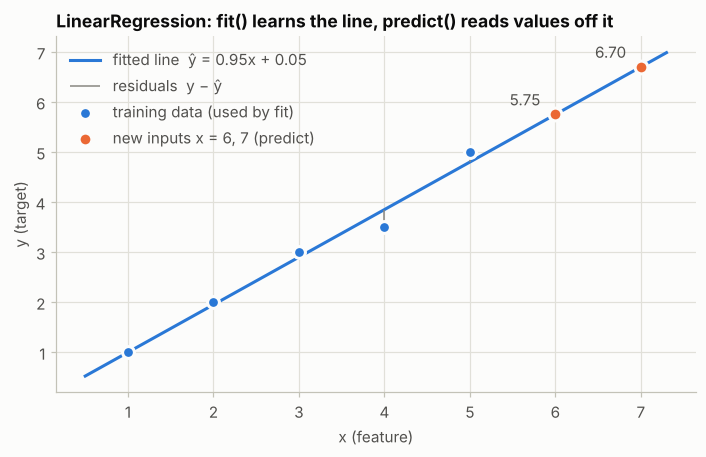

In [5]:
# 🧪 EXTRA — Verify the OLS solution by hand and visualise what fit() and predict() did
x = X.ravel().astype(float)

beta_1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
beta_0 = y.mean() - beta_1 * x.mean()
print(f"closed form      : slope = {beta_1:.4f}, intercept = {beta_0:.4f}")

X_design = np.column_stack([np.ones_like(x), x])  # a column of ones carries the intercept
beta_hat = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)
print(f"normal equations : slope = {beta_hat[1]:.4f}, intercept = {beta_hat[0]:.4f}")
print(f"scikit-learn     : slope = {model.coef_[0]:.4f}, intercept = {model.intercept_:.4f}")
print("hand-made predictions for x = 6, 7:", beta_0 + beta_1 * X_new.ravel())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x_line = np.linspace(0.5, 7.3, 100)
ax.plot(x_line, model.predict(x_line.reshape(-1, 1)), color=PALETTE[0], label="fitted line  ŷ = 0.95x + 0.05")
ax.vlines(x, y, model.predict(X), color=MUTED, linewidth=1, label="residuals  y − ŷ")
ax.scatter(x, y, s=60, color=PALETTE[0], edgecolor=SURFACE, linewidth=2, zorder=3, label="training data (used by fit)")
ax.scatter(X_new.ravel(), predictions, s=70, color=PALETTE[1], edgecolor=SURFACE, linewidth=2, zorder=3,
           label="new inputs x = 6, 7 (predict)")
for x_value, y_value in zip(X_new.ravel(), predictions):
    ax.annotate(f"{y_value:.2f}", (x_value, y_value), textcoords="offset points", xytext=(-30, 6), color=INK_SOFT)
ax.set(xlabel="x (feature)", ylabel="y (target)", title="LinearRegression: fit() learns the line, predict() reads values off it")
ax.legend(loc="upper left")
plt.show()

### 📖 Theory: `fit_predict()` and K-means clustering

**Unsupervised learning** has no target $\mathbf{y}$; the goal is to discover structure in $X$ alone. K-means partitions the $n$ points into $K$ clusters $C_1, \dots, C_K$ by minimising the **within-cluster sum of squares**, which scikit-learn calls *inertia*:

$$J(C_1,\dots,C_K) = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2, \qquad \boldsymbol{\mu}_k = \frac{1}{|C_k|}\sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i .$$

`fit()` runs **Lloyd's algorithm**:

1. *Initialise* $K$ centroids (scikit-learn uses *k-means++* seeding, which spreads the initial centroids apart).
2. *Assignment step* — assign each point to its nearest centroid.
3. *Update step* — move each centroid to the mean of the points assigned to it.
4. Repeat steps 2–3 until the assignments stop changing.

Neither step can increase $J$, so the algorithm always converges — but only to a **local** minimum that depends on the initialisation. That is why K-means is restarted several times (`n_init`) and the run with the lowest inertia is kept.

**Why does `fit_predict()` exist?** For K-means, `fit_predict(X)` is equivalent to `fit(X).labels_`: the cluster labels of the very points used for fitting. In supervised learning we deliberately keep `fit()` and `predict()` apart, because a model must be judged on data it has **not** seen (a hold-out set) — predictions on the training data are optimistically biased.

**Inductive vs. transductive clustering.** K-means can label *new* points (nearest centroid), so it offers `predict()`. Algorithms such as `DBSCAN` or `AgglomerativeClustering` only define labels for the points they were fitted on: they provide `fit_predict()` but **no** `predict()`, so for them `fit_predict()` is the only way to obtain labels.

In [6]:
# 📘 BOOK CODE — fit_predict() with K-means (p. 4)
# Fit_predict is not used in LinearRegression,
# but as an example for clustering:
from sklearn.cluster import KMeans

# Example data
X = np.array([[1], [2], [3], [4], [5]])

# KMeans Clustering example
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X)
print(labels)

# Output: [0,0,0,1,1]

[0 0 0 1 1]


**Output analysis.** The cell prints `[0 0 0 1 1]`, exactly the book's output: the clusters $\{1, 2, 3\}$ and $\{4, 5\}$. That match is partly luck. The listing does not fix `random_state` (here the result is only reproducible because of the global `np.random.seed(0)` in the setup cell), and without a seed the very same code can legitimately print a *different-looking* result such as `[1 1 1 0 0]` or `[1 1 0 0 0]`. There are two independent reasons:

1. **Label switching.** Cluster IDs are arbitrary names — `[0,0,0,1,1]` and `[1,1,1,0,0]` describe the same partition.
2. **A genuine tie in this dataset.** The partitions $A = \{1,2,3\} \mid \{4,5\}$ and $B = \{1,2\} \mid \{3,4,5\}$ have *exactly* the same inertia:

$$J_A = \underbrace{(1-2)^2 + (2-2)^2 + (3-2)^2}_{2} + \underbrace{(4-4.5)^2 + (5-4.5)^2}_{0.5} = 2.5$$

$$J_B = \underbrace{(1-1.5)^2 + (2-1.5)^2}_{0.5} + \underbrace{(3-4)^2 + (4-4)^2 + (5-4)^2}_{2} = 2.5$$

Both are global optima, so which one K-means returns depends only on the random initialisation. The next cells make this visible — and show why `random_state` should be set whenever results must be reproducible.

In [7]:
# 🧪 EXTRA — Same data, different seeds: label switching and a genuine tie
from sklearn.cluster import DBSCAN

rows = []
for seed in range(6):
    km = KMeans(n_clusters=2, random_state=seed).fit(X)
    clusters = sorted((sorted(X[km.labels_ == k].ravel().tolist()) for k in np.unique(km.labels_)), key=min)
    rows.append({
        "random_state": seed,
        "labels_": km.labels_.tolist(),
        "partition": " | ".join(str(c) for c in clusters),
        "cluster_centers_": np.round(km.cluster_centers_.ravel(), 2).tolist(),
        "inertia_": km.inertia_,
    })
display(pd.DataFrame(rows).set_index("random_state"))

km = KMeans(n_clusters=2, random_state=0)
same = np.array_equal(km.fit_predict(X), KMeans(n_clusters=2, random_state=0).fit(X).labels_)
print("fit_predict(X) == fit(X).labels_ :", same)
print("predict() on new points 0, 2.6, 10 ->", km.predict(np.array([[0], [2.6], [10]])))
print("does DBSCAN have predict()?       :", hasattr(DBSCAN(), "predict"), "(only fit_predict)")

,labels_,partition,cluster_centers_,inertia_
random_state,,,,
0,"[0, 0, 0, 1, 1]","[1, 2, 3] | [4, 5]","[2.0, 4.5]",2.5
1,"[0, 0, 0, 1, 1]","[1, 2, 3] | [4, 5]","[2.0, 4.5]",2.5
2,"[1, 1, 0, 0, 0]","[1, 2] | [3, 4, 5]","[4.0, 1.5]",2.5
3,"[0, 0, 0, 1, 1]","[1, 2, 3] | [4, 5]","[2.0, 4.5]",2.5
4,"[1, 1, 1, 0, 0]","[1, 2, 3] | [4, 5]","[4.5, 2.0]",2.5
5,"[0, 0, 0, 1, 1]","[1, 2, 3] | [4, 5]","[2.0, 4.5]",2.5


fit_predict(X) == fit(X).labels_ : True
predict() on new points 0, 2.6, 10 -> [0 0 1]
does DBSCAN have predict()?       : False (only fit_predict)


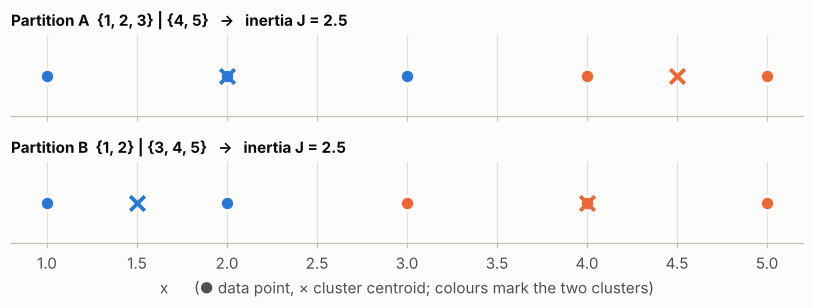

In [8]:
# 🧪 EXTRA — The two equally good partitions of [1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, 1, figsize=(7.5, 2.9), sharex=True)
partitions = {"Partition A  {1, 2, 3} | {4, 5}": np.array([0, 0, 0, 1, 1]),
              "Partition B  {1, 2} | {3, 4, 5}": np.array([0, 0, 1, 1, 1])}
values = X.ravel()
for ax, (title, part) in zip(axes, partitions.items()):
    inertia = 0.0
    for k in (0, 1):
        members = values[part == k]
        inertia += ((members - members.mean()) ** 2).sum()
        ax.scatter(members, np.zeros_like(members), s=90, color=PALETTE[k], edgecolor=SURFACE, linewidth=2, zorder=3)
        ax.scatter(members.mean(), 0, marker="x", s=90, color=PALETTE[k], linewidth=2.5, zorder=4)
    ax.set_title(f"{title}   →   inertia J = {inertia:.1f}", fontsize=10)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.spines["left"].set_visible(False)
axes[-1].set_xlabel("x      (● data point, × cluster centroid; colours mark the two clusters)")
plt.tight_layout()
plt.show()

**Output analysis.** Across seeds the label vectors change, but every run lands on one of the two partitions with inertia exactly 2.5 — both are optimal, and the initialisation decides between them. `fit_predict()` gives the same labels as `fit().labels_`, K-means can still label unseen points with `predict()` (each goes to the nearest centroid), and `DBSCAN` has no `predict()` at all — the inductive/transductive distinction from the theory section.

---
## 3. Transformers and the `transform()` method

### 📝 Summary

* **Transformers** modify data — scaling, normalisation, encoding — to prepare it for modelling.
* They share one interface: **`fit()`** learns the parameters of the transformation from the data and **`transform()`** applies them. `StandardScaler()`, for instance, computes each feature's mean and standard deviation in `fit()` and turns every value into a **z-score** in `transform()`.
* Why transform at all? Many models presuppose well-behaved data (e.g. normally distributed, free of outliers), and real-world data rarely arrive in that neat-and-tidy form.
* **`fit_transform()`** performs both steps in one call. Use it on the **training data**. On the **test data**, call only `transform()`: re-fitting would impose a *different* transformation and make predictions unreliable — the test set must be treated exactly like the training data.
* This consistency lets transformers be integrated into ML pipelines, ensuring that training and test data receive the same transformation — something that becomes critical for production models. (Chapter 2 explores `StandardScaler()`, `MinMaxScaler()` and `OneHotEncoder()` in depth.)
* The book's **Figure 1.1** illustrates data transformation in the context of the `Pipeline()` class.

### 📖 Theory: standardisation and the "learned state" of a transformer

**Z-score standardisation.** For each feature $j$, `StandardScaler` estimates during `fit()`

$$\mu_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij}, \qquad \sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_{ij}-\mu_j)^2}$$

and applies $z_{ij} = (x_{ij} - \mu_j)/\sigma_j$ during `transform()`. Two details are worth knowing:

* $\sigma_j$ is the **population** standard deviation (division by $n$, NumPy's default `ddof=0`), not the sample version (division by $n-1$).
* Standardisation is an **affine** map — a shift plus a rescaling. It gives every feature mean 0 and variance 1 but **does not change the shape** of the distribution: skewed data stay skewed and do not become "normal". Making data look more Gaussian requires a non-linear, shape-changing transformer such as `PowerTransformer` or `QuantileTransformer`.

*By hand for the book's data:* column 1 is $[1, 3, 5]$, so $\mu = 3$ and $\sigma = \sqrt{(4 + 0 + 4)/3} = \sqrt{8/3} \approx 1.63299$, giving $z = [-2, 0, 2]/1.63299 = [-1.2247,\ 0,\ 1.2247]$. Column 2, $[2, 4, 6]$, has $\mu = 4$ and the same $\sigma$, hence the same z-scores.

**When does scaling matter?**

| Model family | Effect of feature scale |
|---|---|
| Distance-based: k-NN, K-means, SVM with RBF kernel | Features with large ranges dominate the Euclidean distance |
| Gradient-based optimisation: logistic regression, neural networks, SGD | Badly scaled features stretch the loss surface → slow or unstable convergence |
| Regularised models: Ridge, Lasso, `C` in logistic regression | The penalty (e.g. $\lambda\sum_j \beta_j^2$) treats all coefficients alike, which is only fair if features share a scale |
| PCA | Looks for directions of maximum variance → dominated by large-scale features |
| Decision trees, random forests, gradient boosting | Invariant to monotonic rescaling — scaling is unnecessary |

**A transformer is a function with learned parameters.** Write it as $T_{\theta}$. `fit()` estimates $\hat\theta = (\hat\mu, \hat\sigma)$ from the **training data only**; `transform()` then applies $T_{\hat\theta}$ to *any* data:

* `scaler.fit(X_train)` estimates $\hat\theta_{\text{train}}$ ✅ — `scaler.transform(X_test)` reuses $\hat\theta_{\text{train}}$ ✅
* `StandardScaler().fit_transform(X_test)` estimates a new $\hat\theta_{\text{test}}$ ❌ — the same raw value now maps to a different z-score than during training, so the model receives inputs on a scale it never saw.
* fitting the scaler on the **whole dataset before splitting** ❌ leaks information about the test set into training (**data leakage**) and makes the evaluation optimistic.

The figure below re-draws the idea of the book's Figure 1.1: inside a `Pipeline`, `fit()` calls `fit_transform()` on every transformer, whereas `predict()` only calls `transform()`, reusing the learned state.

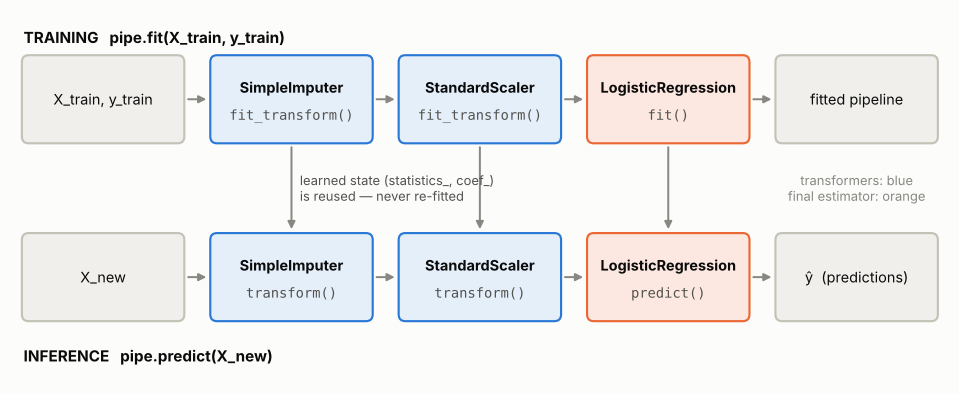

In [9]:
# 🧪 EXTRA — Re-drawing the idea of Figure 1.1: how data flows through a Pipeline
from matplotlib.patches import FancyBboxPatch


def draw_box(ax, x0, y0, width, height, title, subtitle, face, edge):
    ax.add_patch(FancyBboxPatch((x0, y0), width, height, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=face, edgecolor=edge, linewidth=1.4))
    if subtitle:
        ax.text(x0 + width / 2, y0 + height * 0.64, title, ha="center", va="center", fontsize=9.5, color=INK, weight="bold")
        ax.text(x0 + width / 2, y0 + height * 0.30, subtitle, ha="center", va="center", fontsize=9, color=INK_SOFT, family="monospace")
    else:
        ax.text(x0 + width / 2, y0 + height / 2, title, ha="center", va="center", fontsize=9.5, color=INK)


def draw_arrow(ax, start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.3))


fig, ax = plt.subplots(figsize=(11, 4.4))
ax.set_xlim(0, 11.2)
ax.set_ylim(0, 4.4)
ax.axis("off")

BLUE_WASH, ORANGE_WASH, GREY_WASH = "#e5effa", "#fce8e0", "#f0efec"
step_names = ["SimpleImputer", "StandardScaler", "LogisticRegression"]
xs, width, height = [0.15, 2.4, 4.65, 6.9, 9.15], 1.9, 1.0
rows = [
    (2.85, "TRAINING   pipe.fit(X_train, y_train)", ["X_train, y_train", "fit_transform()", "fit_transform()", "fit()", "fitted pipeline"], 4.08),
    (0.75, "INFERENCE   pipe.predict(X_new)", ["X_new", "transform()", "transform()", "predict()", "ŷ  (predictions)"], 0.32),
]
for y0, label, calls, label_y in rows:
    ax.text(0.15, label_y, label, fontsize=10, color=INK, weight="bold", va="center")
    for i, x0 in enumerate(xs):
        if i in (0, 4):
            draw_box(ax, x0, y0, width, height, calls[i], "", GREY_WASH, AXIS)
        else:
            face, edge = (ORANGE_WASH, PALETTE[1]) if i == 3 else (BLUE_WASH, PALETTE[0])
            draw_box(ax, x0, y0, width, height, step_names[i - 1], calls[i], face, edge)
        if i < 4:
            draw_arrow(ax, (x0 + width + 0.03, y0 + height / 2), (xs[i + 1] - 0.03, y0 + height / 2))
for i in (1, 2, 3):   # the learned state travels from the training row to the inference row
    draw_arrow(ax, (xs[i] + width / 2, 2.85 - 0.03), (xs[i] + width / 2, 0.75 + height + 0.03))
ax.text(xs[1] + width / 2 + 0.1, 2.3, "learned state (statistics_, coef_)\nis reused — never re-fitted", fontsize=8.5, color=INK_SOFT, va="center")
ax.text(xs[4] + width / 2, 2.3, "transformers: blue\nfinal estimator: orange", fontsize=8.5, color=MUTED, ha="center", va="center")
plt.show()

In [10]:
# 📘 BOOK CODE — StandardScaler with fit() and transform() (p. 5)
from sklearn.preprocessing import StandardScaler
import numpy as np

# Example data
X = np.array([[1, 2], [3, 4], [5, 6]])

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler on the data
scaler.fit(X)

# Transform the data
X_scaled = scaler.transform(X)
print(X_scaled)

# Output: [[-1.22474487 -1.22474487]
#  [ 0.          0.        ]
#  [ 1.22474487  1.22474487]]

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [11]:
# 📘 BOOK CODE — the fit_transform() shortcut (p. 6)
from sklearn.preprocessing import StandardScaler
import numpy as np

# Example data
X = np.array([[1, 2], [3, 4], [5, 6]])

# Create a StandardScaler instance and
# fit_transform the data in one step
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

# Output: [[-1.22474487 -1.22474487]
#  [ 0.          0.        ]
#  [ 1.22474487  1.22474487]]

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


**Output analysis.** Both listings print the same matrix as the book, and it matches the hand calculation: each column becomes $[-1.2247, 0, 1.2247]$. The two columns end up identical because $[2, 4, 6]$ is just $[1, 3, 5]$ shifted by one, and a shift disappears once the mean is subtracted. `fit()` followed by `transform()` and the single `fit_transform()` call give the same result on the training data; the difference matters only for *new* data, which must go through `transform()` alone.

In [12]:
# 🧪 EXTRA — Look inside the fitted transformer (its learned state)
print("mean_           :", scaler.mean_)            # μ of each feature
print("var_            :", scaler.var_)             # σ² of each feature (population variance)
print("scale_          :", scaler.scale_)           # σ of each feature
print("n_samples_seen_ :", scaler.n_samples_seen_)
print("np.std(ddof=0)  :", X.std(axis=0), "  <- equals scale_")
print("np.std(ddof=1)  :", X.std(axis=0, ddof=1), "  <- does NOT equal scale_")
print("after scaling   : column means =", X_scaled.mean(axis=0), "| column stds =", X_scaled.std(axis=0))
print("inverse_transform() recovers X :", np.allclose(scaler.inverse_transform(X_scaled), X))
print("fit().transform() == fit_transform() :", np.allclose(StandardScaler().fit(X).transform(X), X_scaled))

mean_           : [3. 4.]
var_            : [2.66666667 2.66666667]
scale_          : [1.63299316 1.63299316]
n_samples_seen_ : 3.0
np.std(ddof=0)  : [1.63299316 1.63299316]   <- equals scale_
np.std(ddof=1)  : [2. 2.]   <- does NOT equal scale_
after scaling   : column means = [0. 0.] | column stds = [1. 1.]
inverse_transform() recovers X : True
fit().transform() == fit_transform() : True


training statistics: mean = 49.87, std = 9.59
new data, transform() with training statistics : mean z = +1.01
new data, re-fitted on itself                  : mean z = +0.00
a raw value of 70 -> z = +2.10 with training statistics, z = +1.03 after re-fitting


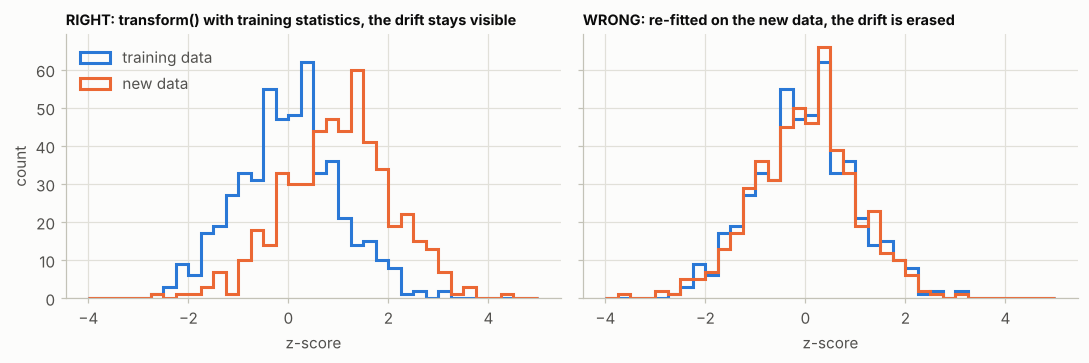

In [13]:
# 🧪 EXTRA — Why new data must only be transform()-ed, never re-fitted
rng = np.random.default_rng(42)
X_train_demo = rng.normal(loc=50, scale=10, size=(500, 1))   # e.g. customer ages seen during training
X_new_demo = rng.normal(loc=60, scale=10, size=(500, 1))     # new data whose distribution has drifted upwards

scaler_demo = StandardScaler().fit(X_train_demo)              # ✅ learn μ and σ on the training data only
z_train = scaler_demo.transform(X_train_demo)
z_right = scaler_demo.transform(X_new_demo)                   # ✅ reuse the training statistics
z_wrong = StandardScaler().fit_transform(X_new_demo)          # ❌ re-fit on the new data

print(f"training statistics: mean = {scaler_demo.mean_[0]:.2f}, std = {scaler_demo.scale_[0]:.2f}")
print(f"new data, transform() with training statistics : mean z = {z_right.mean():+.2f}")
print(f"new data, re-fitted on itself                  : mean z = {z_wrong.mean():+.2f}")
age_70 = np.array([[70.0]])
print(f"a raw value of 70 -> z = {scaler_demo.transform(age_70)[0, 0]:+.2f} with training statistics, "
      f"z = {StandardScaler().fit(X_new_demo).transform(age_70)[0, 0]:+.2f} after re-fitting")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
bins = np.linspace(-4, 5, 37)
panels = [(axes[0], z_right, "RIGHT: transform() with training statistics, the drift stays visible"),
          (axes[1], z_wrong, "WRONG: re-fitted on the new data, the drift is erased")]
for ax, z_new, title in panels:
    ax.hist(z_train.ravel(), bins=bins, histtype="step", linewidth=2, color=PALETTE[0], label="training data")
    ax.hist(z_new.ravel(), bins=bins, histtype="step", linewidth=2, color=PALETTE[1], label="new data")
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel("z-score")
axes[0].set_ylabel("count")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

**Output analysis.** The new data really are shifted (their mean is about one training standard deviation higher). Transforming them with the *training* statistics keeps that information: the new z-scores are centred near $+1$. Re-fitting the scaler on the new data forces their mean back to 0 and the same raw value of 70 receives a completely different z-score — the model would be fed numbers on a scale it never saw, and a genuine change in the data (*data drift*, a key concern of MLOps in recipe 5) would be silently hidden.

---
## 4. Handling custom estimators and transformers

### 📝 Summary

* scikit-learn's API is **extensible**: by subclassing **`BaseEstimator`** together with **mixin classes**, developers can implement their own ML algorithms or data transformations.
* A custom object must follow the interface — `fit()` + `transform()` for transformers, `fit()` + `predict()` for models — which keeps it compatible with tools such as `GridSearchCV()` and `Pipeline()`.
* A **mixin** groups common functionality that many classes need, so the code is written once and included wherever it is required — code reuse instead of repetition.
* The book lists the elements needed to do this well — parameter validation with `check_is_fitted()`, hyperparameter management, integration into pipelines, and testing custom objects with scikit-learn's utilities so they work with cross-validation and preprocessing like built-in estimators — and covers them in later chapters.

> The book gives **no code** for this recipe. Following the assignment note (*"if any task does not involve coding, focus on providing a comprehensive explanation"*), the theory is explained below and then demonstrated with two complete, tested custom estimators.

### 📖 Theory: the estimator contract

To behave like a native scikit-learn object, a class must follow a few rules (from the *Developing scikit-learn estimators* guide):

1. **`__init__` only stores hyperparameters**, each as an attribute with *exactly* the same name as the argument — no validation, no computation, no data. `get_params()`, `set_params()` and `clone()` work by reading the `__init__` signature, so extra logic there breaks them.
2. **`fit(X, y=None)`** validates the input, learns from it, stores the learned values in attributes ending with `_`, and **returns `self`** (enabling chains such as `est.fit(X).transform(X)`).
3. **`transform()` / `predict()`** first check that the estimator is fitted (`check_is_fitted`), validate the new input against what `fit()` saw (same number of features), and never modify the learned state.
4. Randomness, if any, is controlled through a `random_state` hyperparameter.

**What the base classes provide**

| Class | Provides |
|---|---|
| `BaseEstimator` | `get_params()`, `set_params()`, a readable `repr`, the HTML diagram, `clone()` support, default **tags**, version-checked pickling |
| `TransformerMixin` | `fit_transform()` (and `set_output()` support) |
| `ClassifierMixin` | `score()` = accuracy, plus the "classifier" tag |
| `RegressorMixin` | `score()` = $R^2$, plus the "regressor" tag |
| `ClusterMixin` | `fit_predict()` |

**A precision about mixins.** The book describes mixins as extending classes *without* traditional inheritance. In Python, mixins are in fact implemented **through (multiple) inheritance**; what makes a class a mixin is its *role*: it is never instantiated on its own and it adds a capability ("can `fit_transform`") instead of defining what the object *is*.

**Order matters — the Method Resolution Order (MRO).** With multiple inheritance Python looks up methods in the parent classes from left to right (C3 linearisation). The scikit-learn convention is

```python
class MyTransformer(TransformerMixin, BaseEstimator):  # mixins on the LEFT, BaseEstimator on the RIGHT
    ...
```

Every mixin's `__sklearn_tags__()` calls `super().__sklearn_tags__()` and then adds its own information; `BaseEstimator` sits at the end of that chain and creates the default tags. If `BaseEstimator` is listed first, its method runs first, the chain stops there, and the mixin's tags are silently lost — demonstrated at the end of this recipe.

**Validation helpers.** `validate_data()` (public since scikit-learn 1.6) converts and checks the input and records `n_features_in_` / `feature_names_in_`; `check_is_fitted()` raises `NotFittedError` if `fit()` has not been called; `check_estimator()` runs the library's own API-conformance test suite against any estimator.

#### 🧪 Custom transformer: `QuantileClipper` (winsorisation)

**Winsorisation** limits the influence of outliers by pulling every value below the $q_{\text{low}}$ quantile up to that quantile and every value above the $q_{\text{high}}$ quantile down to it:

$$T(x_{ij}) = \min\big(\max(x_{ij},\ L_j),\ U_j\big), \qquad L_j = Q_j(q_{\text{low}}), \quad U_j = Q_j(q_{\text{high}}),$$

where $Q_j$ is the quantile function of feature $j$. The bounds $L_j, U_j$ are **learned in `fit()` from the training data** and then frozen — exactly the fit/transform discipline of recipe 3.

In [14]:
# 🧪 EXTRA — A custom transformer that follows every scikit-learn convention
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.exceptions import NotFittedError
from sklearn.utils.multiclass import check_classification_targets
from sklearn.utils.validation import check_is_fitted, validate_data


class QuantileClipper(TransformerMixin, BaseEstimator):
    """Clip (winsorise) every feature to quantile bounds learned on the training data.

    Parameters
    ----------
    lower_quantile, upper_quantile : float in [0, 1]
        Quantiles used as the lower and upper clipping bounds.
    """

    def __init__(self, lower_quantile=0.05, upper_quantile=0.95):
        # Rule 1: only store the hyperparameters, under the same names
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        # Rule 2: validate, learn, store attributes ending in "_", return self
        X = validate_data(self, X, ensure_all_finite="allow-nan")
        if not 0.0 <= self.lower_quantile < self.upper_quantile <= 1.0:
            raise ValueError("Expected 0 <= lower_quantile < upper_quantile <= 1.")
        self.lower_bounds_ = np.nanquantile(X, self.lower_quantile, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper_quantile, axis=0)
        return self

    def transform(self, X):
        # Rule 3: check the fitted state, validate against fit(), never change the learned state
        check_is_fitted(self)
        X = validate_data(self, X, reset=False, ensure_all_finite="allow-nan")
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def __sklearn_tags__(self):
        # A custom tag (see recipe 8): missing values are accepted and passed through unchanged
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags


rng = np.random.default_rng(0)
X_demo = rng.normal(size=(200, 2))
X_demo[:3] = [[8.0, -9.0], [-7.5, 10.0], [12.0, 0.5]]  # inject three extreme outliers

clipper = QuantileClipper(lower_quantile=0.01, upper_quantile=0.99)
X_clipped = clipper.fit_transform(X_demo)  # fit_transform() is inherited from TransformerMixin
print("learned lower_bounds_ :", clipper.lower_bounds_.round(3))
print("learned upper_bounds_ :", clipper.upper_bounds_.round(3))
print("largest |value| before:", np.abs(X_demo).max().round(2), "| after:", np.abs(X_clipped).max().round(2))
print("n_features_in_ (recorded by validate_data):", clipper.n_features_in_)

learned lower_bounds_ : [-2.938 -2.412]
learned upper_bounds_ : [2.808 2.558]
largest |value| before: 12.0 | after: 2.94
n_features_in_ (recorded by validate_data): 2


In [15]:
# 🧪 EXTRA — Everything BaseEstimator gives us for free
print("repr         :", clipper)                                   # only non-default values are shown
print("get_params() :", clipper.get_params())
print("set_params() :", clipper.set_params(upper_quantile=0.95))   # returns self, so calls can be chained
print("note: set_params() does not re-fit -> upper_bounds_ still", clipper.upper_bounds_.round(3))

fresh = clone(clipper)                                              # same hyperparameters, no learned state
print("clone()      :", fresh.get_params(), "| has learned state:", hasattr(fresh, "lower_bounds_"))
try:
    fresh.transform(X_demo)
except NotFittedError as err:
    print("NotFittedError ->", err)

repr         : QuantileClipper(lower_quantile=0.01, upper_quantile=0.99)
get_params() : {'lower_quantile': 0.01, 'upper_quantile': 0.99}
set_params() : QuantileClipper(lower_quantile=0.01)
note: set_params() does not re-fit -> upper_bounds_ still [2.808 2.558]
clone()      : {'lower_quantile': 0.01, 'upper_quantile': 0.95} | has learned state: False
NotFittedError -> This QuantileClipper instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


**Output analysis.** The transformer learned one lower and one upper bound per feature and pulled the three injected outliers back to those bounds (the largest absolute value dropped from 12 to below 3), while `fit_transform()` came for free from `TransformerMixin`. `BaseEstimator` supplied a meaningful `repr`, `get_params()`/`set_params()` and `clone()` without any extra code — all three work because `__init__` stores its arguments under their own names. Note that after `set_params(upper_quantile=0.95)` the `repr` only shows `lower_quantile=0.01`, because 0.95 is the default and defaults are hidden. Two behaviours are worth remembering: `set_params()` only changes the configuration (the learned bounds stay as they are until the next `fit()`), and a cloned, unfitted copy refuses to `transform()` thanks to `check_is_fitted()`.

#### 🧪 Custom classifier: `MinkowskiCentroidClassifier`

A **nearest-centroid classifier** summarises every class $k$ by its mean vector $\boldsymbol\mu_k$ (learned in `fit()`) and predicts the class with the closest centroid:

$$\hat{y}(\mathbf{x}) = \arg\min_{k} \; \lVert \mathbf{x} - \boldsymbol\mu_k \rVert_p, \qquad \lVert \mathbf{v} \rVert_p = \Big(\sum_{j} |v_j|^p\Big)^{1/p}.$$

$p = 2$ is the Euclidean distance and $p = 1$ the Manhattan distance; $p$ becomes a hyperparameter that can be tuned. (With $p = 2$, equal class priors and Gaussian classes that share a spherical covariance $\sigma^2 I$, this simple rule coincides with the Bayes-optimal classifier.)

In [16]:
# 🧪 EXTRA — A custom classifier
class MinkowskiCentroidClassifier(ClassifierMixin, BaseEstimator):
    """Predict the class whose training centroid is closest in Minkowski-p distance."""

    def __init__(self, p=2.0):
        self.p = p

    def fit(self, X, y):
        X, y = validate_data(self, X, y)
        check_classification_targets(y)  # refuse continuous targets
        if self.p < 1:
            raise ValueError("p must be >= 1 for the Minkowski distance to be a metric.")
        self.classes_, y_encoded = np.unique(y, return_inverse=True)
        self.centroids_ = np.vstack([X[y_encoded == k].mean(axis=0) for k in range(len(self.classes_))])
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, reset=False)
        diff = np.abs(X[:, np.newaxis, :] - self.centroids_[np.newaxis, :, :])  # (n_samples, n_classes, n_features)
        distances = (diff ** self.p).sum(axis=2) ** (1.0 / self.p)
        return self.classes_[np.argmin(distances, axis=1)]

In [17]:
# 🧪 EXTRA — Custom objects plug straight into Pipeline, cross-validation and GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline

X_bc, y_bc = load_breast_cancer(return_X_y=True)  # 569 tumours, 30 features, malignant vs. benign
custom_pipe = Pipeline([
    ("clip", QuantileClipper()),
    ("scale", StandardScaler()),
    ("clf", MinkowskiCentroidClassifier()),
])
scores = cross_val_score(custom_pipe, X_bc, y_bc, cv=5)
print("5-fold CV accuracy:", scores.round(3), "-> mean", scores.mean().round(3))

search = GridSearchCV(custom_pipe, param_grid={"clip__upper_quantile": [0.95, 0.99, 1.0], "clf__p": [1, 1.5, 2, 3]}, cv=5)
search.fit(X_bc, y_bc)
print("best parameters  :", search.best_params_)
print("best CV accuracy :", round(search.best_score_, 3))

5-fold CV accuracy: [0.886 0.93  0.965 0.93  0.956] -> mean 0.933


best parameters  : {'clf__p': 1, 'clip__upper_quantile': 0.95}
best CV accuracy : 0.935


In [18]:
# 🧪 EXTRA — Run scikit-learn's own API-conformance test suite on both classes
from sklearn.utils.estimator_checks import check_estimator

for estimator in [QuantileClipper(), MinkowskiCentroidClassifier()]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # hides the notice that the optional array-API check is skipped
        results = check_estimator(estimator, on_fail=None)
    status = pd.Series([result["status"] for result in results]).value_counts().to_dict()
    print(f"{type(estimator).__name__:<28} {len(results)} checks -> {status}")

QuantileClipper              46 checks -> {'passed': 45, 'skipped': 1}
MinkowskiCentroidClassifier  55 checks -> {'passed': 54, 'skipped': 1}


In [19]:
# 🧪 EXTRA — Why mixins must come BEFORE BaseEstimator
from sklearn.utils import get_tags


class WrongOrderTransformer(BaseEstimator, TransformerMixin):  # ❌ BaseEstimator listed first
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X


print("MRO, wrong order:", [cls.__name__ for cls in WrongOrderTransformer.__mro__])
print("MRO, right order:", [cls.__name__ for cls in QuantileClipper.__mro__])
print("transformer_tags, wrong order ->", get_tags(WrongOrderTransformer()).transformer_tags)
print("transformer_tags, right order ->", get_tags(QuantileClipper()).transformer_tags)

MRO, wrong order: ['WrongOrderTransformer', 'BaseEstimator', 'ReprHTMLMixin', '_HTMLDocumentationLinkMixin', '_MetadataRequester', 'TransformerMixin', '_SetOutputMixin', 'object']
MRO, right order: ['QuantileClipper', 'TransformerMixin', '_SetOutputMixin', 'BaseEstimator', 'ReprHTMLMixin', '_HTMLDocumentationLinkMixin', '_MetadataRequester', 'object']
transformer_tags, wrong order -> None
transformer_tags, right order -> TransformerTags(preserves_dtype=['float64'])


**Output analysis.**

* The custom pipeline — our clipper, a standard scaler and our classifier — cross-validates and grid-searches like any built-in estimator. The nested names `clip__upper_quantile` and `clf__p` exist only because `get_params()` could introspect our `__init__` methods; no extra code was needed for tuning.
* `check_estimator()` ran dozens of API-conformance checks per class (input validation, `clone()` safety, pickling, consistent `n_features_in_`, behaviour on edge cases…) with no failures; the single skipped check concerns optional Array API support.
* With `BaseEstimator` on the left, the MRO calls `BaseEstimator.__sklearn_tags__` first, and the `transformer_tags` contributed by `TransformerMixin` disappear (`None`). With the conventional order the tags are present. Tools that rely on tags — `check_estimator`, `Pipeline`, `set_output` — would mis-handle the wrongly ordered class even though its methods "work".

---
## 5. Pipelines and workflow automation

### 📝 Summary

* ML workflows usually progress linearly through sequential steps, although production systems add extra steps that form a **cycle** — model monitoring, continuous training and CI/CD, as practised in **MLOps**.
* In scikit-learn, **pipelines** automate a workflow by chaining preprocessing, training and prediction into a single cohesive object, so that every step runs consistently and in the right order.
* **MLOps** integrates ML into the software development and operations life cycle — automating development, testing, deployment and maintenance so models stay scalable, reliable and sustainable. The book gives four reasons why it matters: (1) it bridges data science, ML engineering and operations teams, (2) it improves collaboration, (3) it speeds up deployment through automation and reproducibility, and (4) it improves monitoring, observability and explainability against problems such as **model drift** and technical debt. "There is no such thing as a model that works well forever!"
* scikit-learn supports MLOps with `Pipeline()` (automating preprocessing and modelling), `GridSearchCV()` (hyperparameter optimisation) and persistence through **joblib** and **pickle**, and its models integrate with platforms such as **MLflow** and **Kubeflow**.
* Pipelines that combine transformers like `ColumnTransformer()` with estimators like `RandomForestClassifier()` remove manual intervention and make the process reproducible and modular. *(The book refers to "Chapter 14" for this; in the published edition these pipelines are built hands-on in Chapter 2's "Introduction to pipelines in scikit-learn" recipe and used throughout the book — Chapter 14 is the "Unlock Your Exclusive Benefits" section.)*

> No code in the book for this recipe either — the experiments below build exactly the pipeline the book describes.

### 📖 Theory: pipelines as function composition

**Composition.** A pipeline with transformers $T_1, \dots, T_K$ and a final estimator $E$ computes

$$\hat{\mathbf{y}} = E_{\hat\theta_E}\Big(T_{\hat\theta_K}\big(\cdots T_{\hat\theta_2}(T_{\hat\theta_1}(X))\cdots\big)\Big).$$

* `pipe.fit(X, y)`: for $k = 1, \dots, K$ call `fit_transform` on the output of the previous step (learning $\hat\theta_k$), then call `fit` on the final estimator (learning $\hat\theta_E$).
* `pipe.predict(X_new)`: call `transform` with the *frozen* $\hat\theta_1, \dots, \hat\theta_K$, then `predict` with $\hat\theta_E$.

**A pipeline is itself an estimator** (the *composite* design pattern). It therefore has `fit`, `predict`, `score`, `get_params` and `set_params`, and can be handed to `cross_val_score` or `GridSearchCV` as a single unit. Parameters of inner steps are addressed as `step__parameter` (double underscore), e.g. `model__max_depth`.

**Pipelines prevent data leakage inside cross-validation.** In $k$-fold cross-validation each fold must fit *all* data-dependent steps on its own training part only. If preprocessing — and especially *supervised* preprocessing such as feature selection — is fitted on the full dataset before cross-validation, information from the validation folds leaks into training and the estimate becomes optimistic. This classic mistake is discussed as "the wrong and right way to do cross-validation" in *The Elements of Statistical Learning* (§7.10.2). Putting the step inside the pipeline makes the right way automatic.

**Heterogeneous columns.** `ColumnTransformer` applies different pipelines to different column subsets and concatenates the results side by side, $\big[\, T_{\text{num}}(X_{\text{num}}) \;\big|\; T_{\text{cat}}(X_{\text{cat}}) \,\big]$:

* `SimpleImputer(strategy="median")` fills numeric gaps with the training median (robust to outliers); `strategy="most_frequent"` fills categorical gaps with the training mode.
* `OneHotEncoder` maps a category $c$ out of $m$ possible values to the indicator vector $\mathbf{e}_c \in \{0,1\}^m$; `handle_unknown="ignore"` maps categories never seen during training to the all-zero vector instead of failing in production.

**Persistence and the MLOps loop.** A fitted pipeline can be saved with `joblib.dump()` and restored with `joblib.load()`, so the *exact* preprocessing travels with the model into production. Two cautions: pickle-based files can execute arbitrary code when loaded, so only load files from trusted sources; and record the library versions, because a model saved with one scikit-learn version is not guaranteed to load correctly in another. After deployment the loop continues: monitor for **data drift** (the distribution of $X$ changes) and **concept drift** (the relationship between $X$ and $y$ changes), then retrain and redeploy.

In [20]:
# 🧪 EXTRA — A small, realistic, mixed-type dataset (synthetic, so the notebook runs offline)
rng = np.random.default_rng(42)
n = 600
churn = pd.DataFrame({
    "age": rng.integers(18, 70, n).astype(float),
    "monthly_income": rng.lognormal(mean=8.5, sigma=0.5, size=n).round(0),
    "tenure_months": rng.integers(1, 72, n).astype(float),
    "plan": rng.choice(["basic", "standard", "premium"], n, p=[0.5, 0.3, 0.2]),
    "region": rng.choice(["north", "south", "east", "west"], n),
})
# Ground truth: short tenure, younger age and the basic plan raise the probability of churning
logit = (-1.0 - 0.04 * (churn["tenure_months"] - 36) - 0.03 * (churn["age"] - 44)
         + churn["plan"].map({"basic": 0.8, "standard": 0.0, "premium": -0.9})
         + churn["region"].map({"north": 0.2, "south": -0.2, "east": 0.0, "west": 0.1}))
churn["churned"] = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
# Real data are messy: knock out some values at random
for column, fraction in [("age", 0.05), ("monthly_income", 0.08), ("plan", 0.04)]:
    churn.loc[rng.choice(n, int(fraction * n), replace=False), column] = np.nan

print(churn.shape, "| churn rate:", churn["churned"].mean().round(3))
print("missing values:", churn.isna().sum().to_dict())
churn.head()

(600, 6) | churn rate: 0.342
missing values: {'age': 30, 'monthly_income': 48, 'tenure_months': 0, 'plan': 24, 'region': 0, 'churned': 0}


,age,monthly_income,tenure_months,plan,region,churned
0,22.0,4247.0,31.0,basic,east,1
1,NaN,4667.0,7.0,basic,west,1
2,52.0,4333.0,58.0,premium,west,0
3,40.0,5304.0,61.0,standard,south,0
4,40.0,10257.0,53.0,basic,west,0


In [21]:
# 🧪 EXTRA — The whole workflow as ONE estimator: ColumnTransformer + Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

X_churn, y_churn = churn.drop(columns="churned"), churn["churned"]
X_tr, X_te, y_tr, y_te = train_test_split(X_churn, y_churn, test_size=0.25, stratify=y_churn, random_state=42)

numeric_features = ["age", "monthly_income", "tenure_months"]
categorical_features = ["plan", "region"]
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
churn_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
])

churn_pipe.fit(X_tr, y_tr)  # every step is fitted on the training data only
print(f"train accuracy = {churn_pipe.score(X_tr, y_tr):.3f} | test accuracy = {churn_pipe.score(X_te, y_te):.3f}")
print(f"baseline that always predicts 'stays' = {1 - y_te.mean():.3f}")
print("columns produced by the preprocessing step:", churn_pipe[:-1].get_feature_names_out().tolist())
churn_pipe  # in Jupyter this renders an interactive diagram of the pipeline

train accuracy = 0.864 | test accuracy = 0.780
baseline that always predicts 'stays' = 0.660
columns produced by the preprocessing step: ['num__age', 'num__monthly_income', 'num__tenure_months', 'cat__plan_basic', 'cat__plan_premium', 'cat__plan_standard', 'cat__region_east', 'cat__region_north', 'cat__region_south', 'cat__region_west']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['age','monthly_income','tenure_months','plan','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns t

In [22]:
# 🧪 EXTRA — A pipeline is an estimator: nested parameters, cloning and cross-validation
params = churn_pipe.get_params()
print("tunable parameters in the whole pipeline:", len(params))
print("a few nested names:", [name for name in params if name.startswith("model__")][:4], "...")

shallow = clone(churn_pipe).set_params(model__max_depth=3)  # reach inside without touching the fitted original
print("clone with model__max_depth=3 ->", shallow.named_steps["model"].max_depth,
      "| original still has", churn_pipe.named_steps["model"].max_depth)

cv_scores = cross_val_score(churn_pipe, X_tr, y_tr, cv=5)  # imputation & scaling are re-fitted in every fold
print("5-fold CV accuracy of the full pipeline:", cv_scores.round(3), "-> mean", cv_scores.mean().round(3))

tunable parameters in the whole pipeline: 69
a few nested names: ['model__bootstrap', 'model__ccp_alpha', 'model__class_weight', 'model__criterion'] ...
clone with model__max_depth=3 -> 3 | original still has 6


5-fold CV accuracy of the full pipeline: [0.744 0.767 0.722 0.711 0.744] -> mean 0.738


**Output analysis.** One `fit()` call imputed, scaled and one-hot encoded the data and trained the forest; one `score()` call pushed the test set through *the same, already-fitted* preprocessing. The pipeline clearly beats the trivial baseline that always predicts "stays", and the gap between training and test accuracy is a reminder that training accuracy is optimistic. Because the pipeline is a single estimator, it exposes every inner hyperparameter through the `step__param` naming scheme and can be cloned and cross-validated as a unit — with the preprocessing re-fitted inside every fold.

In [23]:
# 🧪 EXTRA — Data leakage: the wrong and the right way to cross-validate (ESL §7.10.2)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

rng_leak = np.random.RandomState(0)
X_noise = rng_leak.normal(size=(100, 5000))  # 100 samples, 5,000 features of PURE noise
y_noise = rng_leak.randint(0, 2, size=100)   # labels are coin flips: the true accuracy is 50%

# ❌ WRONG: choose the 20 "best" features using ALL the data, then cross-validate
X_selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
wrong = cross_val_score(LogisticRegression(), X_selected, y_noise, cv=5)

# ✅ RIGHT: feature selection is a pipeline step, so it is re-fitted inside every training fold
right = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression()), X_noise, y_noise, cv=5)

print(f"WRONG  (selection outside CV): estimated accuracy = {wrong.mean():.2f}")
print(f"RIGHT  (selection inside CV) : estimated accuracy = {right.mean():.2f}   <- close to the 50% truth")

WRONG  (selection outside CV): estimated accuracy = 0.90
RIGHT  (selection inside CV) : estimated accuracy = 0.57   <- close to the 50% truth


**Output analysis.** The labels are coin flips, so no model can genuinely beat 50 %. Yet the "wrong" procedure reports a very high accuracy: among 5,000 noise features, some correlate with the labels *by chance*, and selecting them on the full dataset lets the validation folds influence the choice. Inside a pipeline the selection only sees each fold's training part and the estimate falls back to roughly chance level. This is the strongest practical argument for the book's advice to wrap preprocessing and modelling in `Pipeline()`.

In [24]:
# 🧪 EXTRA — Persisting the fitted pipeline (the first step towards deployment)
import tempfile
from pathlib import Path

import joblib

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "churn_pipeline.joblib"
    joblib.dump(churn_pipe, path)
    restored = joblib.load(path)  # ⚠️ only ever load files you trust: unpickling can execute code
    identical = np.array_equal(restored.predict(X_te), churn_pipe.predict(X_te))
    print(f"saved {path.stat().st_size / 1024:.0f} KiB | identical predictions after reloading: {identical}")
print("store the environment next to the model:", {"scikit-learn": sklearn.__version__, "numpy": np.__version__})

saved 1158 KiB | identical predictions after reloading: True
store the environment next to the model: {'scikit-learn': '1.9.1', 'numpy': '2.5.3'}


---
## 6. Common attributes and methods

### 📝 Summary

* As models grow more complex they become harder to inspect, but scikit-learn models share **attributes and methods** that reveal what they learned.
* Linear models store their learned **coefficients** in `coef_` and the **intercept** in `intercept_`, which helps to interpret model behaviour.
* The **`score()`** method evaluates a model with a default metric: **accuracy** for classifiers and **R²** for regressors.
* The book's example fits `LinearRegression` and prints the coefficient (0.95), the intercept (≈ 0.05) and R² (≈ 0.981).
* A note of caution: R² can be misleading — it depends on how messy the data are and increases whenever variables are added. The **adjusted R²** penalises the number of variables.

### 📖 Theory: learned attributes, `score()`, R² and adjusted R²

**Naming conventions** (scikit-learn glossary):

| Kind | Convention | Examples |
|---|---|---|
| Hyperparameter | constructor argument, no underscore | `n_estimators`, `C`, `fit_intercept` |
| Learned attribute | **trailing underscore**, exists only after `fit()` | `coef_`, `intercept_`, `classes_`, `n_features_in_`, `feature_names_in_`, `feature_importances_`, `cluster_centers_`, `mean_` |
| Private attribute | leading underscore | internal details, not part of the API |

**The coefficient of determination.** With residual and total sums of squares

$$SS_{\text{res}} = \sum_{i}(y_i - \hat{y}_i)^2, \qquad SS_{\text{tot}} = \sum_{i}(y_i - \bar{y})^2, \qquad R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}},$$

R² is the fraction of the variance of $y$ explained by the model, relative to the naive baseline that always predicts $\bar{y}$. For least squares with an intercept, evaluated on the training data, it lies in $[0, 1]$ and (with one feature) equals the squared correlation $r_{xy}^2$. On *new* data it can be **negative** — the model is then worse than predicting the mean.

*By hand for the book's data:* the predictions $0.95x + 0.05$ are $[1.00, 1.95, 2.90, 3.85, 4.80]$, so the residuals are $[0, 0.05, 0.10, -0.35, 0.20]$ and

$$SS_{\text{res}} = 0 + 0.0025 + 0.01 + 0.1225 + 0.04 = 0.175, \qquad SS_{\text{tot}} = 3.61 + 0.81 + 0.01 + 0.36 + 4.41 = 9.2,$$

$$R^2 = 1 - \frac{0.175}{9.2} = 0.98098 .$$

**Why R² never decreases when variables are added.** The least-squares problem with an extra feature contains the smaller problem as a special case (set the new coefficient to 0), so its minimum $SS_{\text{res}}$ can only be smaller or equal: in-sample R² **never decreases** (the book's "always increase" is the typical case — it stays equal only if the new variable adds nothing at all).

**Adjusted R².** With $n$ samples and $p$ features,

$$\bar{R}^2 = 1 - (1 - R^2)\,\frac{n-1}{n-p-1},$$

which replaces both sums of squares by their unbiased variance estimates. Adding a useless feature increases $p$, so $\bar{R}^2$ is not rewarded by noise — on average it stays close to the true (population) R². For the book's data $\bar{R}^2 = 1 - 0.01902 \times 4/3 = 0.97464$.

**Floating point.** The intercept prints as `0.04999999999999938`, not `0.05`: numbers like 0.05 have no exact binary (IEEE-754) representation and arithmetic accumulates rounding errors of order $10^{-16}$. Compare floats with a tolerance (`np.isclose`), never with `==`.

In [25]:
# 📘 BOOK CODE — Common attributes and methods (p. 9)
from sklearn.linear_model import LinearRegression
import numpy as np

# Example data
X = np.array([[1], [2], [3], [4], [5]])  # Feature matrix
y = np.array([1, 2, 3, 3.5, 5])  # Target values

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Access coefficients (slope of the linear model)
print("Coefficients:", model.coef_)

# Access y-intercept
print("Intercept:", model.intercept_)

# Use score() method to evaluate the model (R-squared value)
print("Model R-squared:", model.score(X, y))

# Output:
# Coefficients: [0.95]
# Intercept: 0.04999999999999938
# Model R-squared: 0.9809782608695652

Coefficients: [0.95]
Intercept: 0.04999999999999938
Model R-squared: 0.9809782608695652


**Output analysis.** All three values match the book digit for digit: slope $0.95$ and intercept $\approx 0.05$ (the hand-derived $\hat y = 0.95x + 0.05$), and $R^2 = 0.98098$, i.e. the line explains about 98 % of the variance of $y$. `coef_` is an array (one entry per feature) while `intercept_` is a scalar, and both carry the trailing underscore because they were *learned*. Note that this R² is computed on the training data — it measures fit, not predictive performance on new data.

In [26]:
# 🧪 EXTRA — R² and adjusted R² by hand
y_hat = model.predict(X)
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
n, p = X.shape
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("residuals      :", np.round(y - y_hat, 3))
print(f"SS_res = {ss_res:.4f} | SS_tot = {ss_tot:.4f}")
print(f"R² by hand     = {r2:.10f}   (score() = {model.score(X, y):.10f})")
print(f"corr(x, y)²    = {np.corrcoef(X.ravel(), y)[0, 1] ** 2:.10f}")
print(f"adjusted R²    = {adjusted_r2:.5f}")
print(f"intercept == 0.05 -> {model.intercept_ == 0.05} | np.isclose(intercept, 0.05) -> {np.isclose(model.intercept_, 0.05)}")

residuals      : [ 0.    0.05  0.1  -0.35  0.2 ]
SS_res = 0.1750 | SS_tot = 9.2000
R² by hand     = 0.9809782609   (score() = 0.9809782609)
corr(x, y)²    = 0.9809782609
adjusted R²    = 0.97464
intercept == 0.05 -> False | np.isclose(intercept, 0.05) -> True


,train R²,adjusted R²,test R²
noise features,,,
0,0.566,0.557,0.550
8,0.638,0.557,0.451
16,0.711,0.558,0.303
24,0.785,0.560,0.040
32,0.860,0.570,-0.427
40,0.932,0.581,-2.218


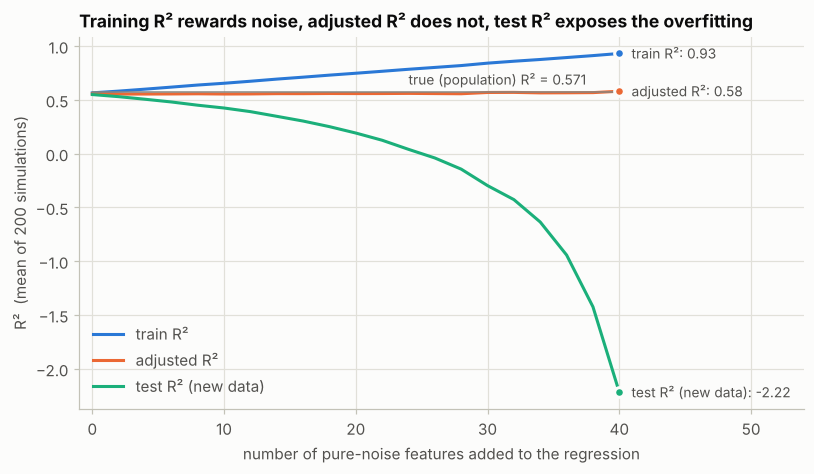

In [27]:
# 🧪 EXTRA — Simulation: what happens to R² when useless (pure-noise) features are added?
rng = np.random.default_rng(0)
n_train, n_test, max_noise, n_repeats = 50, 500, 40, 200
noise_counts = np.arange(0, max_noise + 1, 2)
results = np.zeros((n_repeats, len(noise_counts), 3))  # train R², adjusted R², test R²

for r in range(n_repeats):
    x_tr, x_te = rng.uniform(0, 10, n_train), rng.uniform(0, 10, n_test)
    y_tr = 2 + 0.8 * x_tr + rng.normal(0, 2, n_train)  # the only real signal is x
    y_te = 2 + 0.8 * x_te + rng.normal(0, 2, n_test)
    Z_tr, Z_te = rng.normal(size=(n_train, max_noise)), rng.normal(size=(n_test, max_noise))
    for j, k in enumerate(noise_counts):
        X_tr_k, X_te_k = np.column_stack([x_tr, Z_tr[:, :k]]), np.column_stack([x_te, Z_te[:, :k]])
        lr = LinearRegression().fit(X_tr_k, y_tr)
        r2_train = lr.score(X_tr_k, y_tr)
        adj = 1 - (1 - r2_train) * (n_train - 1) / (n_train - X_tr_k.shape[1] - 1)
        results[r, j] = r2_train, adj, lr.score(X_te_k, y_te)

mean_curves = results.mean(axis=0)
population_r2 = (0.8 ** 2 * 100 / 12) / (0.8 ** 2 * 100 / 12 + 2 ** 2)  # Var(0.8·x) / Var(y) with x ~ U(0, 10)
summary = pd.DataFrame(mean_curves, index=noise_counts, columns=["train R²", "adjusted R²", "test R²"]).round(3)
summary.index.name = "noise features"
display(summary.iloc[::4])

fig, ax = plt.subplots(figsize=(8.5, 4.4))
labels = ["train R²", "adjusted R²", "test R² (new data)"]
for i, label in enumerate(labels):
    ax.plot(noise_counts, mean_curves[:, i], color=PALETTE[i], label=label)
    ax.scatter(noise_counts[-1], mean_curves[-1, i], s=40, color=PALETTE[i], edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.annotate(f"{label}: {mean_curves[-1, i]:.2f}", (noise_counts[-1], mean_curves[-1, i]), xytext=(8, 0),
                textcoords="offset points", va="center", color=INK_SOFT, fontsize=9)
ax.hlines(population_r2, 0, max_noise, color=MUTED, linewidth=1)
ax.annotate(f"true (population) R² = {population_r2:.3f}", (24, population_r2), xytext=(0, 5),
            textcoords="offset points", color=INK_SOFT, fontsize=9)
ax.set(xlabel="number of pure-noise features added to the regression", ylabel="R²  (mean of 200 simulations)",
       title="Training R² rewards noise, adjusted R² does not, test R² exposes the overfitting")
ax.set_xlim(-1, max_noise + 14)
ax.legend(loc="lower left")
plt.show()

**Output analysis.** The book's warning becomes visible:

* **Training R²** climbs steadily even though every added feature is pure noise — least squares always finds *some* chance correlation to exploit.
* **Adjusted R²** stays flat around the true population value (≈ 0.571): on average it does not reward useless variables.
* **Test R²** falls steadily and eventually turns **negative** — the model with many noise features predicts new data worse than a constant. A high training R² is a statement about fit, not about predictive power, which is why later chapters rely on hold-out data and cross-validation.

In [28]:
# 🧪 EXTRA — Attributes you will meet everywhere (classifier edition)
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
clf = LogisticRegression(max_iter=1000).fit(X_iris, y_iris)
print("classes_          :", clf.classes_)
print("n_features_in_    :", clf.n_features_in_)
print("feature_names_in_ :", clf.feature_names_in_.tolist())
print("coef_.shape       :", clf.coef_.shape, "-> one row of weights per class")
print("intercept_        :", clf.intercept_.round(3))
proba = clf.predict_proba(X_iris.iloc[:2])
print("predict_proba()   :", proba.round(3).tolist(), "-> each row sums to", proba.sum(axis=1).round(6))
print("score() = accuracy:", round(clf.score(X_iris, y_iris), 3))

forest = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_iris, y_iris)
print("feature_importances_:", {name: round(float(v), 3) for name, v in zip(iris.feature_names, forest.feature_importances_)})

classes_          : [0 1 2]
n_features_in_    : 4
feature_names_in_ : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
coef_.shape       : (3, 4) -> one row of weights per class
intercept_        : [  9.842   2.225 -12.066]
predict_proba()   : [[0.982, 0.018, 0.0], [0.972, 0.028, 0.0]] -> each row sums to [1. 1.]
score() = accuracy: 0.973


feature_importances_: {'sepal length (cm)': 0.102, 'sepal width (cm)': 0.021, 'petal length (cm)': 0.459, 'petal width (cm)': 0.418}


---
## 7. Hyperparameter tuning with search methods

### 📝 Summary

* Hyperparameter tuning is crucial for optimising candidate models. scikit-learn offers two popular search tools, **`GridSearchCV()`** and **`RandomizedSearchCV()`**, plus counterparts that implement **successive halving**.
* Hyperparameters can also be set **manually**: **`set_params()`** adjusts them programmatically and **`get_params()`** retrieves the current settings — flexible for experiments and combinable with the automated searches.
* The book's example configures a `RandomForestClassifier` with `n_estimators=100`, `max_depth=10`, `random_state=42` and prints the full parameter dictionary.

> **A precision.** The book says the printed dictionary shows the hyperparameters "that provide the best fit". `get_params()` simply reports the *current configuration* — our three values plus the defaults; nothing has been trained or searched yet. The values that worked best are found by a search object and stored in its `best_params_` attribute, as shown below.

### 📖 Theory: tuning as an outer optimisation loop

**Parameters vs. hyperparameters.** Parameters $\theta$ (e.g. `coef_`, the split thresholds of a tree) are learned by `fit()`. Hyperparameters $\lambda$ (e.g. `max_depth`, `C`) are fixed *before* `fit()` and control how the learning happens. Tuning is a two-level optimisation problem:

$$\lambda^{\star} = \arg\min_{\lambda \in \Lambda} \; \widehat{\text{Err}}_{\text{CV}}(\lambda), \qquad \widehat{\text{Err}}_{\text{CV}}(\lambda) = \frac{1}{k}\sum_{j=1}^{k} \text{Err}\big(\hat f_{\lambda}^{(-j)},\ D_j\big),$$

where $\hat f_{\lambda}^{(-j)}$ is trained (inner problem, `fit()`) on all folds except $D_j$ and evaluated on $D_j$.

**`get_params()` / `set_params()`** are what make this outer loop possible: a search object clones the estimator, calls `set_params(**candidate)`, fits and scores it. For composite estimators, `get_params(deep=True)` also returns nested `step__param` keys.

**The three search strategies**

| Strategy | How candidates are chosen | Cost |
|---|---|---|
| `GridSearchCV` | every combination of the listed values (Cartesian product) | $\prod_i \lvert\Lambda_i\rvert \times k$ fits — explodes with the number of hyperparameters |
| `RandomizedSearchCV` | `n_iter` combinations sampled from lists or probability distributions | fixed budget `n_iter` $\times k$, independent of the size of the space |
| `HalvingGridSearchCV` / `HalvingRandomSearchCV` | **successive halving**: all candidates start with a small budget (few samples), only the best $1/\text{factor}$ survive each round, and survivors get $\text{factor}\times$ more budget | most candidates are only ever evaluated cheaply |

*Why random search works* (Bergstra & Bengio, 2012): for most problems only a few hyperparameters really matter. A $3 \times 3$ grid tests only 3 distinct values of each hyperparameter, whereas 9 random draws test 9 distinct values of each — so the important one is explored three times more finely for the same cost. A simple probability argument adds to this: if the best 5 % of the search space counts as "good", the chance that $n$ independent random draws all miss it is $0.95^n$, so with $n = 60$ there is a $1 - 0.95^{60} \approx 95\,\%$ chance that at least one candidate lands in the top 5 %, whatever the number of hyperparameters.

*Successive halving* (Jamieson & Talwalkar, 2016; the idea behind Hyperband) treats candidates like arms of a bandit: cheap, early evaluations eliminate obviously bad configurations so the expensive full-data evaluations are spent on promising ones. In scikit-learn these classes are still **experimental** and require `from sklearn.experimental import enable_halving_search_cv`.

**The winner's curse.** `best_score_` is the maximum of many noisy CV estimates, so it is optimistically biased. Report final performance on an untouched test set (as below) or with nested cross-validation.

In [29]:
# 📘 BOOK CODE — set_params() and get_params() (p. 10)
from sklearn.ensemble import RandomForestClassifier

# Create a RandomForestClassifier model
model = RandomForestClassifier()

# Set hyperparameters prior to training using set_params()
model.set_params(n_estimators=100, max_depth=10, random_state=42)

# Check the updated parameters
print(model.get_params())

# Output: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None,
# 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt',
# 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0,
# 'min_samples_leaf': 1, 'min_samples_split': 2,
# 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None,
# 'n_estimators': 100, 'n_jobs': None, 'oob_score': False,
# 'random_state': 42, 'verbose': 0, 'warm_start': False}

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


**Output analysis.** The dictionary is identical to the book's: the 19 constructor arguments of `RandomForestClassifier`, sorted alphabetically. Three of them carry the values we set (`max_depth=10`, `n_estimators=100`, `random_state=42`) — although `n_estimators=100` happens to be the default already, as the next cell shows. The rest are the library's *sensible defaults*, for example `criterion='gini'`, `bootstrap=True` and `max_features='sqrt'` (each split considers $\sqrt{p}$ randomly chosen features, which de-correlates the trees). Since the model has not been fitted, this output says nothing about which values fit the data best.

In [30]:
# 🧪 EXTRA — get_params()/set_params() in practice
defaults = RandomForestClassifier().get_params()
changed = {name: value for name, value in model.get_params().items() if value != defaults[name]}
print("differs from the defaults :", changed)

model_shallow = clone(model).set_params(max_depth=3)  # set_params returns self -> chainable
print("clone + set_params        :", model_shallow)
pipe_rf = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
print("nested names in a pipeline:", [k for k in pipe_rf.get_params() if k.startswith("randomforestclassifier__max")])

differs from the defaults : {'max_depth': 10, 'random_state': 42}
clone + set_params        : RandomForestClassifier(max_depth=3, random_state=42)
nested names in a pipeline: ['randomforestclassifier__max_depth', 'randomforestclassifier__max_features', 'randomforestclassifier__max_leaf_nodes', 'randomforestclassifier__max_samples']


In [31]:
# 🧪 EXTRA — Automated tuning on real data (breast cancer): grid search ...
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

X_bc, y_bc = load_breast_cancer(return_X_y=True, as_frame=True)
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(X_bc, y_bc, test_size=0.25, stratify=y_bc, random_state=42)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"n_estimators": [50, 100, 200], "max_depth": [3, 6, None], "max_features": ["sqrt", "log2"]}
start = time.perf_counter()
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv5, n_jobs=-1).fit(X_tr_bc, y_tr_bc)
grid_time = time.perf_counter() - start

n_grid = len(grid.cv_results_["params"])
print(f"{n_grid} candidates x {cv5.get_n_splits()} folds = {n_grid * cv5.get_n_splits()} fits (+1 refit on the full training set)")
print("best_params_ :", grid.best_params_)
print(f"best_score_  = {grid.best_score_:.4f} (CV accuracy) | test accuracy = {grid.score(X_te_bc, y_te_bc):.4f}")
leaderboard = pd.DataFrame(grid.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
display(leaderboard.sort_values("rank_test_score").head(5))

18 candidates x 5 folds = 90 fits (+1 refit on the full training set)
best_params_ : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
best_score_  = 0.9648 (CV accuracy) | test accuracy = 0.9580


,params,mean_test_score,std_test_score,rank_test_score
14,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.964815,0.019622,1
13,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.962462,0.017232,2
17,"{'max_depth': None, 'max_features': 'log2', 'n...",0.962462,0.017232,2
10,"{'max_depth': 6, 'max_features': 'log2', 'n_es...",0.960109,0.020476,4
16,"{'max_depth': None, 'max_features': 'log2', 'n...",0.960109,0.020476,4


In [32]:
# 🧪 EXTRA — ... random search with the same budget (18 candidates) ...
param_distributions = {
    "n_estimators": randint(50, 300),  # integers drawn uniformly from [50, 300)
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": randint(1, 10),
}
start = time.perf_counter()
rand = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions, n_iter=18,
                          cv=cv5, random_state=42, n_jobs=-1).fit(X_tr_bc, y_tr_bc)
rand_time = time.perf_counter() - start
print("size of the search space:", 250 * 7 * 3 * 9, "combinations, of which 18 are sampled")
print("best_params_ :", rand.best_params_)
print(f"best_score_  = {rand.best_score_:.4f} (CV accuracy) | test accuracy = {rand.score(X_te_bc, y_te_bc):.4f}")

size of the search space: 47250 combinations, of which 18 are sampled
best_params_ : {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 3, 'n_estimators': 264}
best_score_  = 0.9601 (CV accuracy) | test accuracy = 0.9510


best_params_ : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
best_score_  = 0.9573 (CV accuracy, last round) | test accuracy = 0.9580


,candidates,samples per candidate
round,,
0,18,47
1,6,141
2,2,423


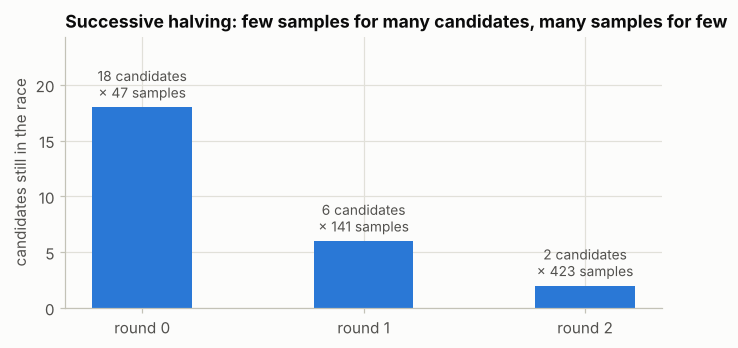

In [33]:
# 🧪 EXTRA — ... and successive halving over the same grid
from sklearn.experimental import enable_halving_search_cv  # noqa: F401  (the API is still experimental)
from sklearn.model_selection import HalvingGridSearchCV

start = time.perf_counter()
halving = HalvingGridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv5, factor=3,
                              random_state=42, n_jobs=-1).fit(X_tr_bc, y_tr_bc)
halving_time = time.perf_counter() - start
print("best_params_ :", halving.best_params_)
print(f"best_score_  = {halving.best_score_:.4f} (CV accuracy, last round) | test accuracy = {halving.score(X_te_bc, y_te_bc):.4f}")

rounds = pd.DataFrame({"candidates": halving.n_candidates_, "samples per candidate": halving.n_resources_})
rounds.index.name = "round"
display(rounds)

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar([f"round {i}" for i in rounds.index], rounds["candidates"], width=0.45, color=PALETTE[0])
for bar, n_samples in zip(bars, rounds["samples per candidate"]):
    ax.annotate(f"{int(bar.get_height())} candidates\n× {n_samples} samples", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", color=INK_SOFT, fontsize=9)
ax.set(ylabel="candidates still in the race", ylim=(0, rounds["candidates"].max() * 1.35),
       title="Successive halving: few samples for many candidates, many samples for few")
plt.show()

In [34]:
# 🧪 EXTRA — Comparing the three strategies
n_train_bc = len(X_tr_bc)
budget = {  # total training samples consumed (candidates x samples), relative to the full grid search
    "GridSearchCV": n_grid * n_train_bc,
    "RandomizedSearchCV": rand.n_iter * n_train_bc,
    "HalvingGridSearchCV": int(np.sum(np.array(halving.n_candidates_) * np.array(halving.n_resources_))),
}
comparison = pd.DataFrame({
    "candidates evaluated": [n_grid, rand.n_iter, int(np.sum(halving.n_candidates_))],
    "relative data budget": [budget[k] / budget["GridSearchCV"] for k in budget],
    "best CV accuracy": [grid.best_score_, rand.best_score_, halving.best_score_],
    "test accuracy": [grid.score(X_te_bc, y_te_bc), rand.score(X_te_bc, y_te_bc), halving.score(X_te_bc, y_te_bc)],
    "wall-clock time (s)": [grid_time, rand_time, halving_time],
}, index=list(budget)).round(3)
display(comparison)

,candidates evaluated,relative data budget,best CV accuracy,test accuracy,wall-clock time (s)
GridSearchCV,18,1.000,0.965,0.958,5.426
RandomizedSearchCV,18,1.000,0.960,0.951,8.018
HalvingGridSearchCV,26,0.331,0.957,0.958,4.756


**Output analysis.**

* **Grid search** evaluated all 18 combinations on full folds. Its leaderboard shows how close the top candidates are — differences of a few tenths of a percent, well within one standard deviation across folds — which is a reminder that `best_params_` is the winner of a noisy race.
* **Random search** spent the same budget on 18 random points of a space with 47,250 combinations — exploring more distinct values of every hyperparameter than the grid could — and found a comparable model (its best CV accuracy is within about half a percentage point of the grid's, i.e. well inside the fold-to-fold noise). With a larger `n_iter` or a different seed it could just as well come out on top.
* **Successive halving** started all 18 grid candidates on a small subsample, kept the best third in every round, and only the last two candidates saw (almost) the full training set. It consumed roughly a third of the grid search's data budget and still agreed with the full grid search on the winning configuration. (Wall-clock times depend on the machine and on parallel overhead; the data budget is the fairer comparison.)
* All three approaches land within about one percentage point of each other on the untouched test set, as expected for close candidates.

---
## 8. Working with metadata: Tags and more

### 📝 Summary

* scikit-learn uses **metadata**, such as **estimator tags**, to control how models behave in different contexts (cross-validation, pipeline processing) and to describe their capabilities, such as supported output types.
* Tags provide information about an estimator — for example whether it can handle **multi-output** data or **missing values** — so scikit-learn can adapt workflows dynamically.
* Metadata about inputs and outputs is used to control the flow of data between the tasks of a pipeline. Metadata objects come in two varieties: **routers**, which pass metadata on, and **consumers**, which use it. This mechanism is called **metadata routing**.
* Metadata routing manages information such as **sample weights**, **group labels** or fit parameters. Example from the book: with an **imbalanced dataset**, sample weights can be routed only to the steps that need them (e.g. the classifier) and ignored by others (e.g. scaling), so the imbalance is handled without distorting preprocessing.
* The book returns to this in Chapters 12 and 13, including how to create custom tags for your own estimators.

### 📖 Theory: estimator tags and metadata routing

**Estimator tags.** Tags are a machine-readable description of what an estimator can do. In scikit-learn ≤ 1.5 (the book's version) they were a private dictionary (`_get_tags()`, `_more_tags()`). Since **1.6** they are a public dataclass returned by `sklearn.utils.get_tags(estimator)` and defined by each class's `__sklearn_tags__()` method:

| Tag group | Examples of fields |
|---|---|
| top level | `estimator_type` (`"classifier"`, `"regressor"`, `"clusterer"`…), `requires_fit`, `non_deterministic`, `array_api_support` |
| `input_tags` | `allow_nan`, `sparse`, `positive_only`, `pairwise`, `categorical`, `string` |
| `target_tags` | `required` (needs `y`?), `multi_output`, `single_output`, `positive_only` |
| `transformer_tags` / `classifier_tags` / `regressor_tags` | e.g. `preserves_dtype`, `multi_class`, `multi_label` |

Tags *drive behaviour*: `is_classifier(est)` reads `estimator_type`, and `cross_val_score(est, X, y, cv=5)` uses it to choose **stratified** folds for classifiers (with a binary or multiclass target) and plain folds otherwise; `check_estimator()` uses tags to decide which tests apply (an estimator that declares `allow_nan=True` is not expected to reject NaNs).

**Metadata routing** (opt-in since scikit-learn 1.3). Some methods accept extra data besides `X` and `y` — `sample_weight` in `fit()` or in scorers, `groups` in CV splitters. A *router* (`Pipeline`, `GridSearchCV`, `cross_validate`…) receives the metadata and must decide which *consumer* gets it. Consumers declare their requests explicitly:

```python
sklearn.set_config(enable_metadata_routing=True)          # or: with sklearn.config_context(...)
LogisticRegression().set_fit_request(sample_weight=True)  # "give me the weights in fit()"
StandardScaler().set_fit_request(sample_weight=False)     # "do NOT give me the weights"
```

A request can be `True` (route it), `False` (don't), an alias string, or unset. If metadata is passed and a consumer that *could* use it has left its request **unset**, scikit-learn raises an `UnsetMetadataPassedError` instead of guessing — a deliberate design choice that prevents silent bugs.

**Sample weights for imbalanced data.** Weighting changes the training objective from $\sum_i \ell(y_i, f(\mathbf{x}_i))$ to $\sum_i w_i\, \ell(y_i, f(\mathbf{x}_i))$. The "balanced" scheme uses

$$w_i = \frac{n}{K \cdot n_{y_i}},$$

with $K$ classes and $n_c$ samples in class $c$, so every class contributes the same total weight to the loss. With 1,900 majority and 100 minority samples ($n = 2000$, $K = 2$): $w_{\text{maj}} = 2000 / (2 \cdot 1900) \approx 0.526$ and $w_{\text{min}} = 2000 / (2 \cdot 100) = 10$. The decision boundary moves towards the majority class, which raises **recall** on the minority class (usually at some cost in precision). **Balanced accuracy**, the mean of the per-class recalls, is a fairer summary than accuracy on such data.

Why not send the weights to the scaler as well? `StandardScaler.fit()` *accepts* `sample_weight`; with balanced weights it would compute a mean and variance in which the 5 % minority counts as much as the 95 % majority, changing the representation of every sample. Usually we want the preprocessing to describe the data as they are and only the *learning objective* to be re-balanced. Routing makes this choice explicit — exactly the book's example.

In [35]:
# 🧪 EXTRA — Reading estimator tags (scikit-learn >= 1.6)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

tag_rows = []
for est in [LinearRegression(), LogisticRegression(), KNeighborsClassifier(), SVC(), RandomForestClassifier(),
            HistGradientBoostingClassifier(), MultinomialNB(), KMeans(), StandardScaler(), SimpleImputer(),
            QuantileClipper()]:
    tags = get_tags(est)
    tag_rows.append({
        "estimator": type(est).__name__,
        "estimator_type": tags.estimator_type or "—",
        "allow_nan": tags.input_tags.allow_nan,
        "sparse input": tags.input_tags.sparse,
        "positive_only X": tags.input_tags.positive_only,
        "multi_output y": tags.target_tags.multi_output,
        "requires y": tags.target_tags.required,
    })
display(pd.DataFrame(tag_rows).set_index("estimator"))

,estimator_type,allow_nan,sparse input,positive_only X,multi_output y,requires y
estimator,,,,,,
LinearRegression,regressor,False,True,False,True,True
LogisticRegression,classifier,False,True,False,False,True
KNeighborsClassifier,classifier,False,True,False,True,True
SVC,classifier,False,True,False,False,True
RandomForestClassifier,classifier,True,True,False,True,True
HistGradientBoostingClassifier,classifier,True,False,False,False,True
MultinomialNB,classifier,False,True,True,False,True
KMeans,clusterer,False,True,False,False,False
StandardScaler,—,True,False,False,False,False


In [36]:
# 🧪 EXTRA — Tags change behaviour: (1) the default CV splitter, (2) missing-value support
from sklearn.base import is_classifier
from sklearn.model_selection import check_cv

y_class, y_cont = np.array([0, 1] * 10), np.linspace(0, 1, 20)
print("cross-validation with cv=5 for a classifier ->",
      type(check_cv(5, y_class, classifier=is_classifier(LogisticRegression()))).__name__)
print("cross-validation with cv=5 for a regressor  ->",
      type(check_cv(5, y_cont, classifier=is_classifier(LinearRegression()))).__name__)

X_nan = np.array([[1.0, 2.0], [np.nan, 1.0], [3.0, np.nan], [4.0, 5.0]] * 10)
y_nan = np.array([0, 1, 0, 1] * 10)
for est in [HistGradientBoostingClassifier(), LogisticRegression()]:
    try:
        est.fit(X_nan, y_nan)
        outcome = "fit() works with NaN"
    except ValueError as err:
        outcome = f"ValueError: {str(err).splitlines()[0]}"
    print(f"{type(est).__name__:<31} allow_nan={get_tags(est).input_tags.allow_nan!s:<5} -> {outcome}")

cross-validation with cv=5 for a classifier -> StratifiedKFold
cross-validation with cv=5 for a regressor  -> KFold


HistGradientBoostingClassifier  allow_nan=True  -> fit() works with NaN
LogisticRegression              allow_nan=False -> ValueError: Input X contains NaN.


**Output analysis.** The tag table is a capability matrix: tree ensembles such as `HistGradientBoostingClassifier` and `RandomForestClassifier` declare `allow_nan=True`, `MultinomialNB` requires non-negative input (it models counts), clusterers and transformers do not require `y`, and our own `QuantileClipper` reports the custom `allow_nan` tag defined in recipe 4. The second cell shows tags at work: the *same* `cv=5` argument produces `StratifiedKFold` for a classifier and `KFold` for a regressor, and the NaN-capable estimator trains on data with missing values while `LogisticRegression` refuses them, exactly as their tags announce.

class counts: [1900  100] | balanced weights per class: [ 0.526 10.   ]
UnsetMetadataPassedError: [sample_weight] are passed but are not explicitly set as requested or not requested for StandardScaler.fit_transform, which is used within Pipeline.fi...


,no weights,weights routed to the classifier
recall (minority class),0.430,0.870
balanced accuracy,0.712,0.875


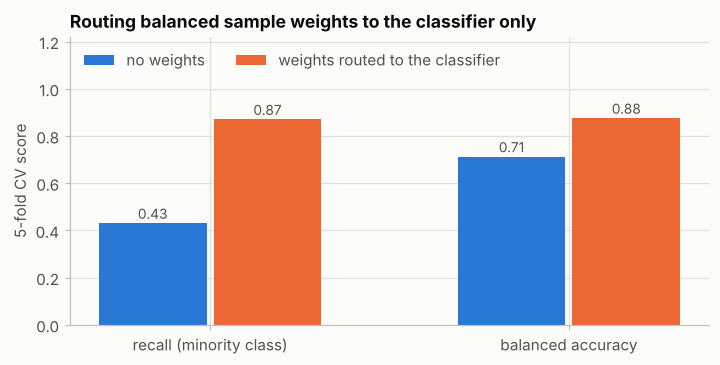

In [37]:
# 🧪 EXTRA — Metadata routing: sample weights for the classifier, NOT for the scaler
from sklearn.datasets import make_classification
from sklearn.metrics import balanced_accuracy_score, make_scorer, recall_score
from sklearn.model_selection import cross_validate
from sklearn.utils.class_weight import compute_sample_weight

X_imb, y_imb = make_classification(n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
                                   weights=[0.95, 0.05], class_sep=1.2, flip_y=0, random_state=7)
weights = compute_sample_weight("balanced", y_imb)
print("class counts:", np.bincount(y_imb), "| balanced weights per class:", np.unique(weights).round(3))
cv_imb = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# 1) Baseline: no weights at all
plain_pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())])
baseline = cross_validate(plain_pipe, X_imb, y_imb, cv=cv_imb,
                          scoring={"recall": "recall", "balanced_accuracy": "balanced_accuracy"})

with sklearn.config_context(enable_metadata_routing=True):
    # 2) Ambiguous request: the scaler could also consume sample_weight but did not say whether it wants it
    ambiguous = Pipeline([("scaler", StandardScaler()),
                          ("clf", LogisticRegression().set_fit_request(sample_weight=True))])
    try:
        ambiguous.fit(X_imb, y_imb, sample_weight=weights)
    except Exception as err:
        print(f"{type(err).__name__}: {str(err).splitlines()[0][:150]}...")

    # 3) Explicit routing: classifier requests the weights, scaler declines them
    routed_pipe = Pipeline([
        ("scaler", StandardScaler().set_fit_request(sample_weight=False)),
        ("clf", LogisticRegression().set_fit_request(sample_weight=True)),
    ])
    scoring = {  # scorers are consumers too: evaluate on the natural, unweighted test folds
        "recall": make_scorer(recall_score).set_score_request(sample_weight=False),
        "balanced_accuracy": make_scorer(balanced_accuracy_score).set_score_request(sample_weight=False),
    }
    weighted = cross_validate(routed_pipe, X_imb, y_imb, cv=cv_imb, scoring=scoring,
                              params={"sample_weight": weights})  # the router splits and dispatches the weights

routing_results = pd.DataFrame({
    "no weights": [baseline["test_recall"].mean(), baseline["test_balanced_accuracy"].mean()],
    "weights routed to the classifier": [weighted["test_recall"].mean(), weighted["test_balanced_accuracy"].mean()],
}, index=["recall (minority class)", "balanced accuracy"]).round(3)
display(routing_results)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
positions, bar_w = np.arange(len(routing_results.index)), 0.3
for i, column in enumerate(routing_results.columns):
    bars = ax.bar(positions + (i - 0.5) * (bar_w + 0.02), routing_results[column], width=bar_w, color=PALETTE[i], label=column)
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", color=INK_SOFT, fontsize=9)
ax.set_xticks(positions, routing_results.index)
ax.set(ylim=(0, 1.22), ylabel="5-fold CV score", title="Routing balanced sample weights to the classifier only")
ax.legend(loc="upper left", ncol=2)
plt.show()

**Output analysis.**

* With 95 % of the samples in one class, the unweighted model favours the majority: it finds only 43 % of the minority cases.
* Enabling routing but leaving the scaler's request **unset** raises `UnsetMetadataPassedError`: scikit-learn refuses to guess whether the scaler should be weighted.
* With explicit requests — weights to `LogisticRegression.fit()`, but not to `StandardScaler.fit()` and not to the scorers — minority-class recall roughly doubles (0.43 → 0.87) and balanced accuracy rises from 0.71 to 0.88, while the preprocessing is untouched. This is the book's imbalanced-data example, implemented.

In [38]:
# 🧪 EXTRA — Routing group labels to a CV splitter (e.g. several samples per patient or per customer)
from sklearn.model_selection import GroupKFold

groups = np.repeat(np.arange(40), 50)  # 40 groups (e.g. customers) with 50 samples each
with sklearn.config_context(enable_metadata_routing=True):
    group_cv = cross_validate(plain_pipe, X_imb, y_imb, cv=GroupKFold(n_splits=5), params={"groups": groups})
print("GroupKFold accuracy per fold:", group_cv["test_score"].round(3))
print("a group never appears in both the training and the test part of a fold -> no leakage across groups")

GroupKFold accuracy per fold: [0.955 0.958 0.962 0.978 0.978]
a group never appears in both the training and the test part of a fold -> no leakage across groups


---
## 9. Best practices for API usage

### 📝 Summary

Following best practices keeps scikit-learn code clear, modular and maintainable: reuse components such as pipelines, stick to the consistent `fit()`/`predict()`/`transform()` methods, use the tuning tools, and keep models and processing steps modular for easy debugging and scaling. The book's key takeaways:

* **Uniform API** — all estimators follow the same `fit()`, `transform()` (transformers) and `predict()` pattern, which makes code more readable, maintainable and easier to develop.
* **Data preprocessing** — always preprocess data (scaling, encoding, handling missing values) with the appropriate tools from `sklearn.preprocessing` before feeding it to the model.
* **Pipelines** — for workflows with several transformations and models, chain them with `Pipeline()` to simplify the code and the hyperparameter tuning.
* **Cross-validation** — evaluate models with the cross-validation tools of `sklearn.model_selection` to obtain a reliable estimate of their generalisation ability.
* **Hyperparameter tuning** — use `GridSearchCV()` or `RandomizedSearchCV()` to find optimal hyperparameters.

### 📖 Theory: why these practices work

* **Uniform API → generic code.** Because every estimator has the same methods, benchmarking loops, pipelines and search tools can treat models as interchangeable parts (recipe 1).
* **Preprocessing inside the workflow.** Every learned transformation must be estimated on training data only (recipe 3); doing it inside a pipeline guarantees this even inside cross-validation (recipe 5).
* **Cross-validation estimates generalisation.** $k$-fold CV trains $k$ models, each validated on a different fold, and averages the scores. The mean estimates the expected performance on new data; the spread across folds shows how uncertain that estimate is. Use **stratified** folds for classification, **group-aware** folds when samples are not independent (`GroupKFold`) and **time-ordered** folds for temporal data (`TimeSeriesSplit`).
* **Tune on training data, test once.** Hyperparameters are chosen by cross-validation *within* the training set; the test set is used a single time at the end, because every additional look at it turns it into a validation set and biases the estimate (recipe 7).
* **Reproducibility.** Fix `random_state`, record library versions and persist the whole fitted pipeline (recipe 5).
* **No free lunch.** Wolpert (1996) showed that, averaged over all possible problems, no learning algorithm outperforms any other. In practice this means there is no universally best model: candidate models must be compared empirically on *your* data — which the uniform API makes cheap.

In [39]:
# 🧪 EXTRA — Capstone: every convention from this chapter in one short workflow
from sklearn.metrics import classification_report

# 1) Data as a DataFrame; keep a stratified, reproducible test set aside
X_bc, y_bc = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)

# 2) Preprocessing + model as ONE estimator; keep pandas column names flowing through the steps
pipe = Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))])
pipe.set_output(transform="pandas")

# 3) Tune C (inverse regularisation strength) with stratified 5-fold CV on the training set only
search = GridSearchCV(pipe, {"clf__C": np.logspace(-3, 2, 11)}, scoring="accuracy",
                      cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)).fit(X_train, y_train)
print(f"best C = {search.best_params_['clf__C']:.4f} | CV accuracy = {search.best_score_:.4f}")

# 4) Evaluate ONCE on the untouched test set
print(classification_report(y_test, search.predict(X_test), target_names=["malignant", "benign"], digits=3))

# 5) Inspect what was learned through the common attributes of the refitted best pipeline
best_clf = search.best_estimator_.named_steps["clf"]
coefs = pd.Series(best_clf.coef_[0], index=best_clf.feature_names_in_)
print("largest standardised coefficients (negative = pushes towards 'malignant'):")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(5).round(3).to_string())

best C = 0.1000 | CV accuracy = 0.9824
              precision    recall  f1-score   support

   malignant      0.976     0.952     0.964        42
      benign      0.973     0.986     0.979        72

    accuracy                          0.974       114
   macro avg      0.974     0.969     0.972       114
weighted avg      0.974     0.974     0.974       114

largest standardised coefficients (negative = pushes towards 'malignant'):
worst texture          -0.564
worst radius           -0.509
worst concave points   -0.508
worst perimeter        -0.466
worst area             -0.460


**Output analysis.** In about twenty lines the workflow uses every idea of the chapter: a uniform estimator API, preprocessing inside a `Pipeline`, `set_output` to keep feature names, cross-validated tuning through the nested name `clf__C`, a single final evaluation on held-out data, and inspection of learned attributes (`coef_`, `feature_names_in_`) on `best_estimator_`. Because the features were standardised, the coefficients are comparable: each one is the change in the log-odds of "benign" (class 1) per standard deviation of the feature. The five largest are all *negative* "worst"-case measurements — texture, radius, concave points, perimeter and area — so larger, more irregular tumours push the prediction towards "malignant", which matches medical intuition. The tuned model reaches about 97 % accuracy on the 114 untouched test tumours.

---
## ✅ Chapter summary and key takeaways

| Concept | API | Role | Recipe |
|---|---|---|---|
| Estimator | `fit()` | learns parameters from data and stores them as `attribute_` | 2 |
| Predictor | `predict()`, `predict_proba()`, `score()` | applies what was learned | 2, 6 |
| Unsupervised shortcut | `fit_predict()` | labels for the training data itself (clustering) | 2 |
| Transformer | `fit()`, `transform()`, `fit_transform()` | learns and applies a data transformation | 3 |
| Custom objects | `BaseEstimator` + mixins, `validate_data`, `check_is_fitted`, `check_estimator` | extend the library safely | 4 |
| Pipeline | `Pipeline`, `ColumnTransformer`, `step__param` | one leakage-free estimator for the whole workflow | 5 |
| Inspection | `coef_`, `intercept_`, `classes_`, `n_features_in_`, `feature_importances_` | understand the fitted model | 6 |
| Hyperparameters | `get_params()`, `set_params()`, `clone()`, `GridSearchCV`, `RandomizedSearchCV`, `Halving*SearchCV` | configure and tune | 7 |
| Metadata | `get_tags()`, `set_fit_request()`, `enable_metadata_routing` | describe capabilities, route `sample_weight` / `groups` | 8 |

**Key takeaways**

1. Learn the pattern once — *instantiate → fit → predict / transform* — and it applies to every one of the library's roughly 200 estimators.
2. `fit()` is the only place where learning happens, and everything learned ends with an underscore.
3. Fit transformers on training data only and merely `transform()` everything else; pipelines enforce this automatically, even inside cross-validation.
4. Hyperparameters are plain constructor arguments; `get_params()`/`set_params()` make them searchable, and a search's `best_params_` — not `get_params()` — tells you which values worked best.
5. Scores computed on training data (R², accuracy) are optimistic; judge models on held-out data or with cross-validation.
6. Metadata — tags and routing — is how scikit-learn's tools adapt to each estimator and how extra information reaches exactly the right step.

**Book (scikit-learn 1.5) vs. the version used here — notes from the reproduction**

* All six listings run unchanged and reproduce the printed outputs; the K-means labels can differ only through the label switching and the tie explained in recipe 2.
* Estimator tags became a public, dataclass-based API in scikit-learn 1.6 (`sklearn.utils.get_tags`, `__sklearn_tags__`), replacing the private `_get_tags()`/`_more_tags()` of 1.5; `validate_data()` also became public in 1.6.
* Small precisions to the chapter text: `get_params()` shows the *current* configuration rather than hyperparameters "that provide the best fit"; in-sample R² *never decreases* when variables are added; mixins are implemented through multiple inheritance; and the pipeline material announced for "Chapter 14" appears in Chapter 2 of this edition.

## 📚 References

1. Sukup, J. (2025). *scikit-learn Cookbook* (3rd ed.). Packt Publishing. Code repository: <https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition>
2. Buitinck, L., Louppe, G., Blondel, M., Pedregosa, F., Mueller, A., Grisel, O., … Varoquaux, G. (2013). API design for machine learning software: experiences from the scikit-learn project. *ECML PKDD Workshop: Languages for Data Mining and Machine Learning*. <https://arxiv.org/abs/1309.0238>
3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
4. Bergstra, J., & Bengio, Y. (2012). Random Search for Hyper-Parameter Optimization. *Journal of Machine Learning Research, 13*, 281–305. <https://jmlr.org/papers/v13/bergstra12a.html>
5. Jamieson, K., & Talwalkar, A. (2016). Non-stochastic Best Arm Identification and Hyperparameter Optimization. *AISTATS 2016*.
6. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.), §7.10.2 "The Wrong and Right Way to Do Cross-validation". Springer.
7. Wolpert, D. H. (1996). The Lack of A Priori Distinctions Between Learning Algorithms. *Neural Computation, 8*(7), 1341–1390.
8. scikit-learn documentation: [About us (project history)](https://scikit-learn.org/stable/about.html) · [Glossary](https://scikit-learn.org/stable/glossary.html) · [Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html) · [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) · [Tuning hyper-parameters](https://scikit-learn.org/stable/modules/grid_search.html) · [Metadata routing](https://scikit-learn.org/stable/metadata_routing.html) · [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) · [Model persistence](https://scikit-learn.org/stable/model_persistence.html)